# ViTAM-SlowFast Pipeline for Pig Behavior Classification

This notebook documents the complete ViTAM-SlowFast experimental workflow used as an RGB-based spatio-temporal baseline for pig behavior recognition. The workflow is organized around ground-truth crop sequences extracted from the annotated video dataset and evaluates behavior classification under two experimental settings: the original six-class scenario and the aggregated four-class scenario.

The notebook includes: dataset loading and temporal sampling, the adapted ViTAM-SlowFast architecture, a model sanity check, fold-based training, final metric consolidation, inference-time benchmarking, and export of prediction artifacts for downstream statistical comparison and reproducibility. Explanatory Markdown cells were added before each executable cell to clarify the purpose, expected inputs, main operations, generated outputs, and how each step contributes to the overall experimental pipeline.

The code assumes that the processed visual dataset, fold definitions, label maps, and output directories are already available on disk. Paths may need to be adjusted when reproducing the experiments on another machine.


# ViTAM-SlowFast Adaptation for 5 fps Ground-Truth Crop Sequences

# Preparing the Dataset with Ground-Truth Crops

## Reproducibility step: =========================================================

This cell is part of the ViTAM-SlowFast experimental workflow. It prepares inputs, executes model-related processing, or generates artifacts required for training, evaluation, benchmarking, or result consolidation. Keeping this step documented helps make the notebook easier to audit and rerun when reproducing the reported experiments.

In [10]:
# =========================================================
# DATASET + COLLATE FUNCTION (required before training)
# =========================================================

import numpy as np
import pandas as pd
import torch
import cv2
from pathlib import Path
from torch.utils.data import Dataset

class PigSlowFastDataset(Dataset):
    def __init__(self, csv_path, src_frames=15, fast_frames=32, slow_frames=8, img_size=224):
        self.df = pd.read_csv(csv_path).reset_index(drop=True)
        self.src_frames = src_frames
        self.fast_frames = fast_frames
        self.slow_frames = slow_frames
        self.img_size = img_size

        self.fast_idx = np.linspace(0, self.src_frames - 1, self.fast_frames).round().astype(int)
        self.slow_idx = np.linspace(0, self.fast_frames - 1, self.slow_frames).round().astype(int)

    def __len__(self):
        return len(self.df)

    def _load_src_clip(self, clip_dir):
        frames = []
        clip_dir = Path(clip_dir)

        for t in range(self.src_frames):
            p = clip_dir / f"img_{t:03d}.jpg"
            img = cv2.imread(str(p))
            if img is None:
                raise ValueError(f"Erro ao ler: {p}")

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (self.img_size, self.img_size))
            img = img.astype(np.float32) / 255.0

            mean = np.array([0.45, 0.45, 0.45], dtype=np.float32)
            std = np.array([0.225, 0.225, 0.225], dtype=np.float32)
            img = (img - mean) / std

            img = np.transpose(img, (2, 0, 1))
            frames.append(img)

        return np.stack(frames, axis=0)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        src_clip = self._load_src_clip(row["clip_dir"])

        fast = src_clip[self.fast_idx]
        fast = np.transpose(fast, (1, 0, 2, 3))
        slow = fast[:, self.slow_idx, :, :]

        slow = torch.tensor(slow, dtype=torch.float32)
        fast = torch.tensor(fast, dtype=torch.float32)
        y = int(row["label_idx"])

        meta = {
            "clip_name": row["clip_name"],
            "clip_idx": int(row["clip_idx"]),
            "track_id": int(row["track_id"]),
            "start_frame": int(row["start_frame"]),
            "label_name": row["label_name"],
        }

        return [slow, fast], y, meta


def collate_fn(batch):
    slow = torch.stack([b[0][0] for b in batch])
    fast = torch.stack([b[0][1] for b in batch])
    y = torch.tensor([b[1] for b in batch], dtype=torch.long)
    meta = [b[2] for b in batch]
    return [slow, fast], y, meta


print("✅ PigSlowFastDataset pronto para uso")

✅ PigSlowFastDataset pronto para uso


## Adapted ViTAM-SlowFast architecture

This cell implements the adapted ViTAM-SlowFast model used for pig behavior classification. The model follows the SlowFast idea of processing the same clip through two temporal pathways: a slow pathway for lower-frequency semantic information and a fast pathway for higher-frequency motion cues. A simplified Temporal Adaptive Module is added to reweight temporal features dynamically, allowing the network to emphasize frames that are more informative for behavior discrimination.

The architecture is intentionally compact compared with large video backbones. This makes it suitable as a controlled visual baseline when comparing RGB-based temporal representations against skeleton-based methods such as DeGCN and KP-TCN.

In [3]:
# =========================================================
# ADAPTED ViTAM-SlowFast — initial version
# Ground-truth crop -> class
# =========================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

# ---------------------------------------------------------
# SIMPLE TEMPORAL ADAPTIVE MODULE (simplified TAM)
# ---------------------------------------------------------

class TemporalAdaptiveModule(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        hidden = max(channels // reduction, 8)

        # global branch
        self.fc1 = nn.Linear(channels, hidden)
        self.fc2 = nn.Linear(hidden, channels)

        # local temporal branch
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=3, padding=1, groups=1)

    def forward(self, x):
        # x: [B, C, T, H, W]
        b, c, t, h, w = x.shape

        # spatial summary
        xs = x.mean(dim=[3, 4])              # [B, C, T]

        # local temporal branch
        local_att = torch.sigmoid(self.conv1(xs))   # [B, C, T]
        local_att = local_att.unsqueeze(-1).unsqueeze(-1)  # [B, C, T, 1, 1]

        # global branch
        xg = xs.mean(dim=2)                  # [B, C]
        g = F.relu(self.fc1(xg))
        g = torch.sigmoid(self.fc2(g))       # [B, C]
        g = g.unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)    # [B, C, 1, 1, 1]

        # combinação
        out = x * local_att * g
        return out


# ---------------------------------------------------------
# FAST PATHWAY
# ---------------------------------------------------------

class FastPathway(nn.Module):
    def __init__(self, in_channels=3, base_channels=32, out_dim=256):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv3d(in_channels, base_channels, kernel_size=(3,7,7), stride=(1,2,2), padding=(1,3,3)),
            nn.BatchNorm3d(base_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(1,3,3), stride=(1,2,2), padding=(0,1,1)),
        )

        self.block1 = nn.Sequential(
            nn.Conv3d(base_channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
        )
        self.tam1 = TemporalAdaptiveModule(64)

        self.block2 = nn.Sequential(
            nn.Conv3d(64, 128, kernel_size=3, stride=(1,2,2), padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),
        )
        self.tam2 = TemporalAdaptiveModule(128)

        self.block3 = nn.Sequential(
            nn.Conv3d(128, out_dim, kernel_size=3, stride=(1,2,2), padding=1),
            nn.BatchNorm3d(out_dim),
            nn.ReLU(inplace=True),
        )
        self.tam3 = TemporalAdaptiveModule(out_dim)

        self.pool = nn.AdaptiveAvgPool3d((1,1,1))

    def forward(self, x):
        # x: [B, 3, 32, 224, 224]
        x = self.stem(x)
        x = self.block1(x)
        x = self.tam1(x)
        x = self.block2(x)
        x = self.tam2(x)
        x = self.block3(x)
        x = self.tam3(x)

        feat_map = x
        x = self.pool(x).flatten(1)
        return x, feat_map


# ---------------------------------------------------------
# PATCH EMBEDDING 3D PARA O CAMINHO LENTO
# ---------------------------------------------------------

class PatchEmbed3D(nn.Module):
    def __init__(self, in_channels=3, embed_dim=256, patch_size=(2,16,16)):
        super().__init__()
        self.proj = nn.Conv3d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        # x: [B, 3, 8, 224, 224]
        x = self.proj(x)                     # [B, E, T', H', W']
        b, e, t, h, w = x.shape
        x = x.flatten(2).transpose(1, 2)    # [B, N, E]
        return x, (t, h, w)


# ---------------------------------------------------------
# SLOW PATHWAY (ViT simplificado)
# ---------------------------------------------------------

class SlowPathwayViT(nn.Module):
    def __init__(self, in_channels=3, embed_dim=256, depth=4, num_heads=8, mlp_ratio=4.0):
        super().__init__()

        self.patch_embed = PatchEmbed3D(in_channels, embed_dim, patch_size=(2,16,16))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            dropout=0.1,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        # x: [B, 3, 8, 224, 224]
        tokens, shape_3d = self.patch_embed(x)
        tokens = self.encoder(tokens)
        tokens = self.norm(tokens)

        # média global dos tokens
        feat = tokens.mean(dim=1)  # [B, E]
        return feat, tokens, shape_3d


# ---------------------------------------------------------
# FUSÃO LATERAL SIMPLIFICADA
# ---------------------------------------------------------

class LateralFusion(nn.Module):
    def __init__(self, fast_dim=256, slow_dim=256, out_dim=256):
        super().__init__()
        self.fast_proj = nn.Linear(fast_dim, out_dim)
        self.slow_proj = nn.Linear(slow_dim, out_dim)

    def forward(self, fast_feat, slow_feat):
        f = self.fast_proj(fast_feat)
        s = self.slow_proj(slow_feat)
        return torch.cat([s, f], dim=1)


# ---------------------------------------------------------
# MODELO FINAL
# ---------------------------------------------------------

class ViTAMSlowFastAdapted(nn.Module):
    def __init__(self, num_classes=6, slow_dim=256, fast_dim=256):
        super().__init__()

        self.slow_path = SlowPathwayViT(
            in_channels=3,
            embed_dim=slow_dim,
            depth=4,
            num_heads=8,
            mlp_ratio=4.0
        )

        self.fast_path = FastPathway(
            in_channels=3,
            base_channels=32,
            out_dim=fast_dim
        )

        self.fusion = LateralFusion(
            fast_dim=fast_dim,
            slow_dim=slow_dim,
            out_dim=256
        )

        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # x = [slow, fast]
        slow_x, fast_x = x

        slow_feat, slow_tokens, slow_shape = self.slow_path(slow_x)
        fast_feat, fast_map = self.fast_path(fast_x)

        fused = self.fusion(fast_feat, slow_feat)
        logits = self.classifier(fused)
        return logits

## Smoke test

This short section marks the beginning of a quick model sanity check. The following cell verifies that the adapted ViTAM-SlowFast architecture can process synthetic slow and fast pathway inputs without dimension errors.

## Model smoke test

This cell performs a minimal forward-pass test of the adapted ViTAM-SlowFast architecture. Random tensors are created with the same dimensionality expected by the slow and fast pathways, and the model output shape is checked. This is a diagnostic step used before training to confirm that the architecture, tensor dimensions, and device placement are consistent.

The number of trainable parameters is also printed to document the model size and support later comparisons with other architectures in terms of computational complexity.

In [5]:
# =========================================================
# QUICK MODEL TEST
# =========================================================

device = "cuda" if torch.cuda.is_available() else "cpu"

model_vitam = ViTAMSlowFastAdapted(num_classes=6).to(device)
model_vitam.eval()

slow = torch.randn(2, 3, 8, 224, 224).to(device)
fast = torch.randn(2, 3, 32, 224, 224).to(device)

with torch.no_grad():
    out = model_vitam([slow, fast])

print("Output shape:", out.shape)
print("Number of parameters:", sum(p.numel() for p in model_vitam.parameters()))

C:\Users\pedro\anaconda3\envs\vision_pose_cuda\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Saída: torch.Size([2, 6])
Nº parâmetros: 5296310


# ViTAM-SlowFast Training for the Six-Class Scenario

## Single-fold training test

This cell runs an initial training test on fold 0. It loads the aligned fold CSV files, builds training and validation datasets, reads the class mapping, initializes the ViTAM-SlowFast model, and trains it for a small number of epochs.

The purpose of this block is not necessarily to produce the final reported result. Instead, it checks whether the complete training loop works correctly before launching the full five-fold experiment. It also verifies that paths, labels, dataloaders, metrics, checkpoint saving, and validation artifacts are compatible.

In [12]:
# =========================================================
# TRAINING TEST — adapted ViTAM-SlowFast — FOLD 0
# =========================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

ROOT = Path(r"F:\slowfast_dataset_degcn_aligned_5300xml")
FOLDS = ROOT / "folds_aligned"
SAVE_DIR = ROOT / "vitam_slowfast_runs" / "fold0_test"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

CSV_TRAIN = FOLDS / "fold0_train.csv"
CSV_VAL   = FOLDS / "fold0_val.csv"

LABELS_MAP = Path(r"F:\meus_dados_degcn_5300f_T15\labels_mix_map.json")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 4
EPOCHS = 5
LR = 1e-4
NUM_WORKERS = 0

with open(LABELS_MAP, "r", encoding="utf-8") as f:
    mp = json.load(f)

if "idx_to_class" in mp:
    idx_to_class = {int(k): v for k, v in mp["idx_to_class"].items()}
elif "class_to_idx" in mp:
    idx_to_class = {int(v): k for k, v in mp["class_to_idx"].items()}
else:
    idx_to_class = {int(k): v for k, v in mp.items()}

class_names = [idx_to_class[i] for i in sorted(idx_to_class)]
NUM_CLASSES = len(class_names)

print("Classes:", class_names)

ds_train = PigSlowFastDataset(CSV_TRAIN, 15, 32, 8, 224)
ds_val   = PigSlowFastDataset(CSV_VAL,   15, 32, 8, 224)

dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=collate_fn)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)

df_train = pd.read_csv(CSV_TRAIN)
counts = df_train["label_idx"].value_counts().sort_index()

weights = np.ones(NUM_CLASSES, dtype=np.float32)
for c in range(NUM_CLASSES):
    n = counts.get(c, 1)
    weights[c] = len(df_train) / (NUM_CLASSES * n)
weights = torch.tensor(weights, dtype=torch.float32, device=DEVICE)

model = ViTAMSlowFastAdapted(num_classes=NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

best_macro_f1 = -1.0
history = []

for epoch in range(EPOCHS):
    print(f"\nEPOCH {epoch+1}/{EPOCHS}")
    model.train()
    train_losses = []

    for i, (x, y, _) in enumerate(dl_train):
        if i % 50 == 0:
            print(f"[TRAIN] batch {i}/{len(dl_train)}")

        x = [t.to(DEVICE) for t in x]
        y = y.to(DEVICE)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    model.eval()
    y_true, y_pred, probs_all, meta_all = [], [], [], []

    with torch.no_grad():
        for i, (x, y, meta_batch) in enumerate(dl_val):
            if i % 50 == 0:
                print(f"[VAL] batch {i}/{len(dl_val)}")

            x = [t.to(DEVICE) for t in x]
            logits = model(x)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            pred = probs.argmax(axis=1)

            y_true.append(y.numpy())
            y_pred.append(pred)
            probs_all.append(probs)
            meta_all.extend(meta_batch)

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    probs_all = np.concatenate(probs_all)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    print(f"train_loss={np.mean(train_losses):.4f} | val_acc={acc:.4f} | val_macro_f1={macro_f1:.4f}")

    history.append({
        "epoch": epoch + 1,
        "train_loss": float(np.mean(train_losses)),
        "val_acc": acc,
        "val_macro_f1": macro_f1,
        "val_weighted_f1": weighted_f1,
    })

    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1

        torch.save(model.state_dict(), SAVE_DIR / "best.pt")

        np.savez_compressed(
            SAVE_DIR / "val_artifacts_best.npz",
            y_true=y_true,
            y_pred=y_pred,
            probs=probs_all
        )

        pd.DataFrame(meta_all).to_csv(SAVE_DIR / "meta_val_best.csv", index=False, encoding="utf-8-sig")

        cm = confusion_matrix(y_true, y_pred, labels=np.arange(NUM_CLASSES))
        pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(
            SAVE_DIR / "confusion_matrix_best.csv", encoding="utf-8-sig"
        )

        rep = classification_report(
            y_true, y_pred,
            labels=np.arange(NUM_CLASSES),
            target_names=class_names,
            output_dict=True,
            zero_division=0
        )
        pd.DataFrame(rep).T.to_csv(
            SAVE_DIR / "classification_report_best.csv", encoding="utf-8-sig"
        )

        pd.DataFrame(history).to_csv(SAVE_DIR / "history.csv", index=False, encoding="utf-8-sig")

print("\n[OK] Fold 0 teste finalizado.")
print("Melhor macro-F1:", best_macro_f1)
print("Artefatos salvos em:", SAVE_DIR)

Classes: ['walking', 'running', 'eating', 'drinking', 'lying awake', 'sleeping']


C:\Users\pedro\anaconda3\envs\vision_pose_cuda\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



EPOCH 1/5
[TRAIN] batch 0/608
[TRAIN] batch 50/608
[TRAIN] batch 100/608
[TRAIN] batch 150/608
[TRAIN] batch 200/608
[TRAIN] batch 250/608
[TRAIN] batch 300/608
[TRAIN] batch 350/608
[TRAIN] batch 400/608
[TRAIN] batch 450/608
[TRAIN] batch 500/608
[TRAIN] batch 550/608
[TRAIN] batch 600/608
[VAL] batch 0/95
[VAL] batch 50/95
train_loss=1.1525 | val_acc=0.4630 | val_macro_f1=0.4692

EPOCH 2/5
[TRAIN] batch 0/608
[TRAIN] batch 50/608
[TRAIN] batch 100/608
[TRAIN] batch 150/608
[TRAIN] batch 200/608
[TRAIN] batch 250/608
[TRAIN] batch 300/608
[TRAIN] batch 350/608
[TRAIN] batch 400/608
[TRAIN] batch 450/608
[TRAIN] batch 500/608
[TRAIN] batch 550/608
[TRAIN] batch 600/608
[VAL] batch 0/95
[VAL] batch 50/95
train_loss=0.8791 | val_acc=0.4868 | val_macro_f1=0.4093

EPOCH 3/5
[TRAIN] batch 0/608
[TRAIN] batch 50/608
[TRAIN] batch 100/608
[TRAIN] batch 150/608
[TRAIN] batch 200/608
[TRAIN] batch 250/608
[TRAIN] batch 300/608
[TRAIN] batch 350/608
[TRAIN] batch 400/608
[TRAIN] batch 450/608


## Adapted ViTAM-SlowFast architecture

This cell implements the adapted ViTAM-SlowFast model used for pig behavior classification. The model follows the SlowFast idea of processing the same clip through two temporal pathways: a slow pathway for lower-frequency semantic information and a fast pathway for higher-frequency motion cues. A simplified Temporal Adaptive Module is added to reweight temporal features dynamically, allowing the network to emphasize frames that are more informative for behavior discrimination.

The architecture is intentionally compact compared with large video backbones. This makes it suitable as a controlled visual baseline when comparing RGB-based temporal representations against skeleton-based methods such as DeGCN and KP-TCN.

In [19]:
# =========================================================
# ADAPTED ViTAM-SlowFast — FIVE-FOLD TRAINING
# saves training history, best model, and fold-level artifacts
# =========================================================

from pathlib import Path
import json
import time
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# =========================================================
# DATASET
# =========================================================

class PigSlowFastDataset(Dataset):
    def __init__(self, csv_path, src_frames=15, fast_frames=32, slow_frames=8, img_size=224):
        self.df = pd.read_csv(csv_path).reset_index(drop=True)
        self.src_frames = src_frames
        self.fast_frames = fast_frames
        self.slow_frames = slow_frames
        self.img_size = img_size

        self.fast_idx = np.linspace(0, self.src_frames - 1, self.fast_frames).round().astype(int)
        self.slow_idx = np.linspace(0, self.fast_frames - 1, self.slow_frames).round().astype(int)

    def __len__(self):
        return len(self.df)

    def _load_src_clip(self, clip_dir):
        frames = []
        clip_dir = Path(clip_dir)

        for t in range(self.src_frames):
            p = clip_dir / f"img_{t:03d}.jpg"
            img = cv2.imread(str(p))
            if img is None:
                raise ValueError(f"Erro ao ler: {p}")

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)
            img = img.astype(np.float32) / 255.0

            mean = np.array([0.45, 0.45, 0.45], dtype=np.float32)
            std = np.array([0.225, 0.225, 0.225], dtype=np.float32)
            img = (img - mean) / std

            img = np.transpose(img, (2, 0, 1))  # HWC -> CHW
            frames.append(img)

        return np.stack(frames, axis=0)  # (T, C, H, W)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        src_clip = self._load_src_clip(row["clip_dir"])

        fast = src_clip[self.fast_idx]            # (32, C, H, W)
        fast = np.transpose(fast, (1, 0, 2, 3))  # (C, 32, H, W)
        slow = fast[:, self.slow_idx, :, :]      # (C, 8, H, W)

        slow = torch.tensor(slow, dtype=torch.float32)
        fast = torch.tensor(fast, dtype=torch.float32)
        y = int(row["label_idx"])

        meta = {
            "clip_name": row["clip_name"],
            "clip_idx": int(row["clip_idx"]),
            "track_id": int(row["track_id"]),
            "start_frame": int(row["start_frame"]),
            "label_name": row["label_name"],
        }

        return [slow, fast], y, meta


def collate_fn(batch):
    slow = torch.stack([b[0][0] for b in batch], dim=0)
    fast = torch.stack([b[0][1] for b in batch], dim=0)
    y = torch.tensor([b[1] for b in batch], dtype=torch.long)
    meta = [b[2] for b in batch]
    return [slow, fast], y, meta

print("✅ Dataset pronto")

# =========================================================
# MODELO ViTAM-SlowFast ADAPTADO
# =========================================================

class TemporalAdaptiveModule(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.fc1 = nn.Linear(channels, hidden)
        self.fc2 = nn.Linear(hidden, channels)
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x):
        # x: [B, C, T, H, W]
        xs = x.mean(dim=[3, 4])                        # [B, C, T]

        local_att = torch.sigmoid(self.conv1(xs))     # [B, C, T]
        local_att = local_att.unsqueeze(-1).unsqueeze(-1)

        xg = xs.mean(dim=2)                           # [B, C]
        g = F.relu(self.fc1(xg))
        g = torch.sigmoid(self.fc2(g))                # [B, C]
        g = g.unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)

        return x * local_att * g


class FastPathway(nn.Module):
    def __init__(self, in_channels=3, base_channels=32, out_dim=256):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv3d(in_channels, base_channels, kernel_size=(3, 7, 7), stride=(1, 2, 2), padding=(1, 3, 3)),
            nn.BatchNorm3d(base_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(1, 3, 3), stride=(1, 2, 2), padding=(0, 1, 1)),
        )

        self.block1 = nn.Sequential(
            nn.Conv3d(base_channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
        )
        self.tam1 = TemporalAdaptiveModule(64)

        self.block2 = nn.Sequential(
            nn.Conv3d(64, 128, kernel_size=3, stride=(1, 2, 2), padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),
        )
        self.tam2 = TemporalAdaptiveModule(128)

        self.block3 = nn.Sequential(
            nn.Conv3d(128, out_dim, kernel_size=3, stride=(1, 2, 2), padding=1),
            nn.BatchNorm3d(out_dim),
            nn.ReLU(inplace=True),
        )
        self.tam3 = TemporalAdaptiveModule(out_dim)

        self.pool = nn.AdaptiveAvgPool3d((1, 1, 1))

    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.tam1(x)
        x = self.block2(x)
        x = self.tam2(x)
        x = self.block3(x)
        x = self.tam3(x)

        feat_map = x
        x = self.pool(x).flatten(1)
        return x, feat_map


class PatchEmbed3D(nn.Module):
    def __init__(self, in_channels=3, embed_dim=256, patch_size=(2, 16, 16)):
        super().__init__()
        self.proj = nn.Conv3d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        x = self.proj(x)                     # [B, E, T', H', W']
        b, e, t, h, w = x.shape
        x = x.flatten(2).transpose(1, 2)    # [B, N, E]
        return x, (t, h, w)


class SlowPathwayViT(nn.Module):
    def __init__(self, in_channels=3, embed_dim=256, depth=4, num_heads=8, mlp_ratio=4.0):
        super().__init__()

        self.patch_embed = PatchEmbed3D(in_channels, embed_dim, patch_size=(2, 16, 16))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            dropout=0.1,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        tokens, shape_3d = self.patch_embed(x)
        tokens = self.encoder(tokens)
        tokens = self.norm(tokens)
        feat = tokens.mean(dim=1)
        return feat, tokens, shape_3d


class LateralFusion(nn.Module):
    def __init__(self, fast_dim=256, slow_dim=256, out_dim=256):
        super().__init__()
        self.fast_proj = nn.Linear(fast_dim, out_dim)
        self.slow_proj = nn.Linear(slow_dim, out_dim)

    def forward(self, fast_feat, slow_feat):
        f = self.fast_proj(fast_feat)
        s = self.slow_proj(slow_feat)
        return torch.cat([s, f], dim=1)


class ViTAMSlowFastAdapted(nn.Module):
    def __init__(self, num_classes=6, slow_dim=256, fast_dim=256):
        super().__init__()

        self.slow_path = SlowPathwayViT(
            in_channels=3,
            embed_dim=slow_dim,
            depth=4,
            num_heads=8,
            mlp_ratio=4.0
        )

        self.fast_path = FastPathway(
            in_channels=3,
            base_channels=32,
            out_dim=fast_dim
        )

        self.fusion = LateralFusion(
            fast_dim=fast_dim,
            slow_dim=slow_dim,
            out_dim=256
        )

        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        slow_x, fast_x = x
        slow_feat, slow_tokens, slow_shape = self.slow_path(slow_x)
        fast_feat, fast_map = self.fast_path(fast_x)
        fused = self.fusion(fast_feat, slow_feat)
        logits = self.classifier(fused)
        return logits

print("✅ Modelo pronto")

# =========================================================
# CONFIG DE TREINO
# =========================================================

ROOT = Path(r"F:\slowfast_dataset_degcn_aligned_5300xml")
FOLDS_DIR = ROOT / "folds_aligned"
SAVE_ROOT = ROOT / "vitam_slowfast_runs_6cls_5fold"
SAVE_ROOT.mkdir(parents=True, exist_ok=True)

LABELS_MAP = Path(r"F:\meus_dados_degcn_5300f_T15\labels_mix_map.json")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 4
NUM_WORKERS = 0
EPOCHS = 50
LR = 1e-4
WEIGHT_DECAY = 1e-4

IMG_SIZE = 224
SRC_FRAMES = 15
FAST_FRAMES = 32
SLOW_FRAMES = 8

print("DEVICE:", DEVICE)

# =========================================================
# CLASSES
# =========================================================

with open(LABELS_MAP, "r", encoding="utf-8") as f:
    mp = json.load(f)

if "idx_to_class" in mp:
    idx_to_class = {int(k): v for k, v in mp["idx_to_class"].items()}
elif "class_to_idx" in mp:
    idx_to_class = {int(v): k for k, v in mp["class_to_idx"].items()}
else:
    idx_to_class = {int(k): v for k, v in mp.items()}

class_names = [idx_to_class[i] for i in sorted(idx_to_class)]
NUM_CLASSES = len(class_names)

print("Classes:", class_names)

with open(SAVE_ROOT / "class_names.json", "w", encoding="utf-8") as f:
    json.dump({"idx_to_class": {str(i): c for i, c in enumerate(class_names)}}, f, ensure_ascii=False, indent=2)

# =========================================================
# LOOP 5 FOLDS
# =========================================================

global_summary = []

for fold in range(5):
    print("\n" + "=" * 70)
    print(f"FOLD {fold}")
    print("=" * 70)

    csv_train = FOLDS_DIR / f"fold{fold}_train.csv"
    csv_val   = FOLDS_DIR / f"fold{fold}_val.csv"

    ds_train = PigSlowFastDataset(csv_train, SRC_FRAMES, FAST_FRAMES, SLOW_FRAMES, IMG_SIZE)
    ds_val   = PigSlowFastDataset(csv_val,   SRC_FRAMES, FAST_FRAMES, SLOW_FRAMES, IMG_SIZE)

    dl_train = DataLoader(
        ds_train, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn
    )
    dl_val = DataLoader(
        ds_val, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn
    )

    print("Train:", len(ds_train))
    print("Val  :", len(ds_val))

    df_train = pd.read_csv(csv_train)
    counts = df_train["label_idx"].value_counts().sort_index()

    weights = np.ones(NUM_CLASSES, dtype=np.float32)
    for c in range(NUM_CLASSES):
        n = counts.get(c, 1)
        weights[c] = len(df_train) / (NUM_CLASSES * n)

    weights = torch.tensor(weights, dtype=torch.float32, device=DEVICE)
    print("Class weights:", weights)

    model = ViTAMSlowFastAdapted(num_classes=NUM_CLASSES).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=3
    )

    best_macro_f1 = -1.0
    best_epoch = -1
    history = []

    fold_dir = SAVE_ROOT / f"fold{fold}"
    fold_dir.mkdir(parents=True, exist_ok=True)

    for epoch in range(EPOCHS):
        t0 = time.time()
        print(f"\n[FOLD {fold}] EPOCH {epoch+1}/{EPOCHS}")

        # ---------------- TRAIN ----------------
        model.train()
        train_losses = []

        for i, (x, y, _) in enumerate(dl_train):
            if i % 100 == 0:
                print(f"[TRAIN] batch {i}/{len(dl_train)}")

            x = [t.to(DEVICE, non_blocking=True) for t in x]
            y = y.to(DEVICE, non_blocking=True)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses)) if len(train_losses) > 0 else np.nan

        # ---------------- VAL ----------------
        model.eval()
        y_true = []
        y_pred = []
        probs_all = []
        meta_all = []
        val_losses = []

        with torch.no_grad():
            for i, (x, y, meta_batch) in enumerate(dl_val):
                if i % 100 == 0:
                    print(f"[VAL] batch {i}/{len(dl_val)}")

                x = [t.to(DEVICE, non_blocking=True) for t in x]
                y_gpu = y.to(DEVICE, non_blocking=True)

                logits = model(x)
                loss_val = criterion(logits, y_gpu)
                val_losses.append(loss_val.item())

                probs = torch.softmax(logits, dim=1).cpu().numpy()
                pred = probs.argmax(axis=1)

                y_true.append(y.numpy())
                y_pred.append(pred)
                probs_all.append(probs)
                meta_all.extend(meta_batch)

        y_true = np.concatenate(y_true)
        y_pred = np.concatenate(y_pred)
        probs_all = np.concatenate(probs_all)

        acc = accuracy_score(y_true, y_pred)
        macro_f1 = f1_score(y_true, y_pred, average="macro")
        weighted_f1 = f1_score(y_true, y_pred, average="weighted")
        val_loss = float(np.mean(val_losses)) if len(val_losses) > 0 else np.nan
        epoch_time = time.time() - t0

        row = {
            "fold": fold,
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_acc": acc,
            "val_macro_f1": macro_f1,
            "val_weighted_f1": weighted_f1,
            "lr": optimizer.param_groups[0]["lr"],
            "epoch_time_sec": epoch_time,
        }
        history.append(row)

        print(
            f"[FOLD {fold}] epoch={epoch+1} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"acc={acc:.4f} | "
            f"macro_f1={macro_f1:.4f} | "
            f"weighted_f1={weighted_f1:.4f} | "
            f"time={epoch_time:.1f}s"
        )

        scheduler.step(macro_f1)

        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_epoch = epoch + 1

            print(f"🔥 [FOLD {fold}] Novo melhor modelo na época {best_epoch} (macro-F1={best_macro_f1:.4f})")

            torch.save(model.state_dict(), fold_dir / "best.pt")

            np.savez_compressed(
                fold_dir / "val_artifacts_best.npz",
                y_true=y_true,
                y_pred=y_pred,
                probs=probs_all
            )

            pd.DataFrame(meta_all).to_csv(
                fold_dir / "meta_val_best.csv",
                index=False,
                encoding="utf-8-sig"
            )

            cm = confusion_matrix(y_true, y_pred, labels=np.arange(NUM_CLASSES))
            pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(
                fold_dir / "confusion_matrix_best.csv",
                encoding="utf-8-sig"
            )

            rep = classification_report(
                y_true, y_pred,
                labels=np.arange(NUM_CLASSES),
                target_names=class_names,
                output_dict=True,
                zero_division=0
            )
            pd.DataFrame(rep).T.to_csv(
                fold_dir / "classification_report_best.csv",
                encoding="utf-8-sig"
            )

            with open(fold_dir / "summary_best.json", "w", encoding="utf-8") as f:
                json.dump(
                    {
                        "fold": fold,
                        "best_epoch": best_epoch,
                        "best_val_acc": acc,
                        "best_val_macro_f1": macro_f1,
                        "best_val_weighted_f1": weighted_f1,
                        "n_train": len(ds_train),
                        "n_val": len(ds_val),
                        "class_names": class_names,
                    },
                    f,
                    ensure_ascii=False,
                    indent=2
                )

        pd.DataFrame(history).to_csv(
            fold_dir / "history.csv",
            index=False,
            encoding="utf-8-sig"
        )

    global_summary.append({
        "fold": fold,
        "best_epoch": best_epoch,
        "best_macro_f1": best_macro_f1,
        "n_train": len(ds_train),
        "n_val": len(ds_val),
    })

global_summary_df = pd.DataFrame(global_summary)
global_summary_df.to_csv(
    SAVE_ROOT / "global_summary_folds.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n[OK] TREINAMENTO ViTAM-SlowFast 5 FOLDS FINALIZADO")
display(global_summary_df)
print("Artefatos salvos em:", SAVE_ROOT)

✅ Dataset pronto
✅ Modelo pronto
DEVICE: cuda
Classes: ['walking', 'running', 'eating', 'drinking', 'lying awake', 'sleeping']

FOLD 0
Train: 2430
Val  : 378
Class weights: tensor([1.2898, 1.8326, 0.6995, 2.3824, 0.8508, 0.6045], device='cuda:0')

[FOLD 0] EPOCH 1/50


C:\Users\pedro\anaconda3\envs\vision_pose_cuda\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[TRAIN] batch 0/608
[TRAIN] batch 100/608
[TRAIN] batch 200/608
[TRAIN] batch 300/608
[TRAIN] batch 400/608
[TRAIN] batch 500/608
[TRAIN] batch 600/608
[VAL] batch 0/95
[FOLD 0] epoch=1 | train_loss=1.1622 | val_loss=1.2699 | acc=0.3942 | macro_f1=0.3362 | weighted_f1=0.3869 | time=358.5s
🔥 [FOLD 0] Novo melhor modelo na época 1 (macro-F1=0.3362)

[FOLD 0] EPOCH 2/50
[TRAIN] batch 0/608
[TRAIN] batch 100/608
[TRAIN] batch 200/608
[TRAIN] batch 300/608
[TRAIN] batch 400/608
[TRAIN] batch 500/608
[TRAIN] batch 600/608
[VAL] batch 0/95
[FOLD 0] epoch=2 | train_loss=0.8874 | val_loss=1.2533 | acc=0.4048 | macro_f1=0.3583 | weighted_f1=0.4208 | time=263.5s
🔥 [FOLD 0] Novo melhor modelo na época 2 (macro-F1=0.3583)

[FOLD 0] EPOCH 3/50
[TRAIN] batch 0/608
[TRAIN] batch 100/608
[TRAIN] batch 200/608
[TRAIN] batch 300/608
[TRAIN] batch 400/608
[TRAIN] batch 500/608
[TRAIN] batch 600/608
[VAL] batch 0/95
[FOLD 0] epoch=3 | train_loss=0.7950 | val_loss=1.3785 | acc=0.4233 | macro_f1=0.3633 | wei

C:\Users\pedro\anaconda3\envs\vision_pose_cuda\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[TRAIN] batch 0/580
[TRAIN] batch 100/580
[TRAIN] batch 200/580
[TRAIN] batch 300/580
[TRAIN] batch 400/580
[TRAIN] batch 500/580
[VAL] batch 0/123
[VAL] batch 100/123
[FOLD 1] epoch=1 | train_loss=1.1809 | val_loss=1.0974 | acc=0.5592 | macro_f1=0.4135 | weighted_f1=0.5236 | time=261.3s
🔥 [FOLD 1] Novo melhor modelo na época 1 (macro-F1=0.4135)

[FOLD 1] EPOCH 2/50
[TRAIN] batch 0/580
[TRAIN] batch 100/580
[TRAIN] batch 200/580
[TRAIN] batch 300/580
[TRAIN] batch 400/580
[TRAIN] batch 500/580
[VAL] batch 0/123
[VAL] batch 100/123
[FOLD 1] epoch=2 | train_loss=0.9251 | val_loss=0.9820 | acc=0.5918 | macro_f1=0.4692 | weighted_f1=0.5901 | time=261.6s
🔥 [FOLD 1] Novo melhor modelo na época 2 (macro-F1=0.4692)

[FOLD 1] EPOCH 3/50
[TRAIN] batch 0/580
[TRAIN] batch 100/580
[TRAIN] batch 200/580
[TRAIN] batch 300/580
[TRAIN] batch 400/580
[TRAIN] batch 500/580
[VAL] batch 0/123
[VAL] batch 100/123
[FOLD 1] epoch=3 | train_loss=0.8315 | val_loss=0.9881 | acc=0.5571 | macro_f1=0.4016 | weight

...

[TRAIN] batch 0/518
[TRAIN] batch 100/518
[TRAIN] batch 200/518
[TRAIN] batch 300/518
[TRAIN] batch 400/518
[TRAIN] batch 500/518
[VAL] batch 0/185
[VAL] batch 100/185
[FOLD 3] epoch=1 | train_loss=1.2907 | val_loss=0.7908 | acc=0.7154 | macro_f1=0.5035 | weighted_f1=0.6812 | time=255.6s
🔥 [FOLD 3] Novo melhor modelo na época 1 (macro-F1=0.5035)

[FOLD 3] EPOCH 2/50
[TRAIN] batch 0/518
[TRAIN] batch 100/518
[TRAIN] batch 200/518
[TRAIN] batch 300/518
[TRAIN] batch 400/518
[TRAIN] batch 500/518
[VAL] batch 0/185
[VAL] batch 100/185
[FOLD 3] epoch=2 | train_loss=1.0250 | val_loss=0.7119 | acc=0.7154 | macro_f1=0.4493 | weighted_f1=0.6649 | time=255.6s

[FOLD 3] EPOCH 3/50
[TRAIN] batch 0/518
[TRAIN] batch 100/518
[TRAIN] batch 200/518
[TRAIN] batch 300/518
[TRAIN] batch 400/518
[TRAIN] batch 500/518
[VAL] batch 0/185
[VAL] batch 100/185
[FOLD 3] epoch=3 | train_loss=0.9165 | val_loss=0.6080 | acc=0.7480 | macro_f1=0.5724 | weighted_f1=0.7381 | time=255.8s
🔥 [FOLD 3] Novo melhor modelo na

C:\Users\pedro\anaconda3\envs\vision_pose_cuda\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[TRAIN] batch 100/549
[TRAIN] batch 200/549
[TRAIN] batch 300/549
[TRAIN] batch 400/549
[TRAIN] batch 500/549
[VAL] batch 0/154
[VAL] batch 100/154
[FOLD 4] epoch=1 | train_loss=1.2962 | val_loss=3.9825 | acc=0.3958 | macro_f1=0.2127 | weighted_f1=0.2805 | time=261.2s
🔥 [FOLD 4] Novo melhor modelo na época 1 (macro-F1=0.2127)

[FOLD 4] EPOCH 2/50
[TRAIN] batch 0/549
[TRAIN] batch 100/549
[TRAIN] batch 200/549
[TRAIN] batch 300/549
[TRAIN] batch 400/549
[TRAIN] batch 500/549
[VAL] batch 0/154
[VAL] batch 100/154
[FOLD 4] epoch=2 | train_loss=0.9420 | val_loss=4.9703 | acc=0.4528 | macro_f1=0.3534 | weighted_f1=0.3250 | time=258.1s
🔥 [FOLD 4] Novo melhor modelo na época 2 (macro-F1=0.3534)

[FOLD 4] EPOCH 3/50
[TRAIN] batch 0/549
[TRAIN] batch 100/549
[TRAIN] batch 200/549
[TRAIN] batch 300/549
[TRAIN] batch 400/549
[TRAIN] batch 500/549
[VAL] batch 0/154
[VAL] batch 100/154
[FOLD 4] epoch=3 | train_loss=0.8214 | val_loss=4.9376 | acc=0.4528 | macro_f1=0.2982 | weighted_f1=0.3154 | time=

,fold,best_epoch,best_macro_f1,n_train,n_val
0,0,6,0.502955,2430,378
1,1,24,0.706790,2318,490
2,2,14,0.683480,2220,588
3,3,6,0.626351,2070,738
4,4,5,0.363511,2194,614


Artefatos salvos em: F:\slowfast_dataset_degcn_aligned_5300xml\vitam_slowfast_runs_6cls_5fold


## Consolidation of six-class ViTAM-SlowFast results

This cell aggregates validation artifacts across the five folds for the six-class experiment. It loads the predictions and probability outputs saved during training, concatenates them, computes global metrics, and generates consolidated reports such as accuracy, macro-F1, weighted-F1, average precision, and confusion matrices.

This consolidation step is important because the final performance reported in the manuscript must reflect all temporal folds together, rather than a single fold in isolation.

Classes: ['walking', 'running', 'eating', 'drinking', 'lying awake', 'sleeping']
Fold 0: n=378 | acc=0.4735 | macro_f1=0.5030
Fold 1: n=490 | acc=0.7041 | macro_f1=0.7068
Fold 2: n=588 | acc=0.7109 | macro_f1=0.6835
Fold 3: n=738 | acc=0.7913 | macro_f1=0.6264
Fold 4: n=614 | acc=0.4788 | macro_f1=0.3635

Total consolidado:
y_true_all: (2808,)
y_pred_all: (2808,)
probs_all : (2808, 6)

=== MÉTRICAS GLOBAIS ===
Accuracy    : 0.648148
Macro-F1    : 0.580188
Weighted-F1 : 0.629511

=== CLASSIFICATION REPORT ===


,precision,recall,f1-score,support
walking,0.509146,0.845570,0.635585,395.000000
running,0.375000,0.013453,0.025974,223.000000
eating,0.812199,0.776074,0.793725,652.000000
drinking,0.791209,0.818182,0.804469,176.000000
lying awake,0.469388,0.550427,0.506688,585.000000
sleeping,0.782542,0.657658,0.714685,777.000000
accuracy,0.648148,0.648148,0.648148,0.648148
macro avg,0.623247,0.610227,0.580188,2808.000000
weighted avg,0.653907,0.648148,0.629511,2808.000000



=== MATRIZ DE CONFUSÃO ===


,walking,running,eating,drinking,lying awake,sleeping
walking,334,5,21,8,26,1
running,220,3,0,0,0,0
eating,26,0,506,1,105,14
drinking,8,0,1,144,18,5
lying awake,63,0,59,19,322,122
sleeping,5,0,36,10,215,511



=== MATRIZ NORMALIZADA ===


...

,class_idx,class_name,AP
0,0,walking,0.509856
1,1,running,0.245926
2,2,eating,0.882858
3,3,drinking,0.859515
4,4,lying awake,0.442563
5,5,sleeping,0.794883



mAP: 0.622600

=== RESUMO POR FOLD ===


,fold,n_samples,accuracy,macro_f1,weighted_f1
0,0,378,0.473545,0.502955,0.458270
1,1,490,0.704082,0.706790,0.704623
2,2,588,0.710884,0.683480,0.713985
3,3,738,0.791328,0.626351,0.798390
4,4,614,0.478827,0.363511,0.353026



=== RESUMO GLOBAL ===


,accuracy,macro_f1,weighted_f1,mAP,AP_walking,AP_running,AP_eating,AP_drinking,AP_lying awake,AP_sleeping
0,0.648148,0.580188,0.629511,0.6226,0.509856,0.245926,0.882858,0.859515,0.442563,0.794883


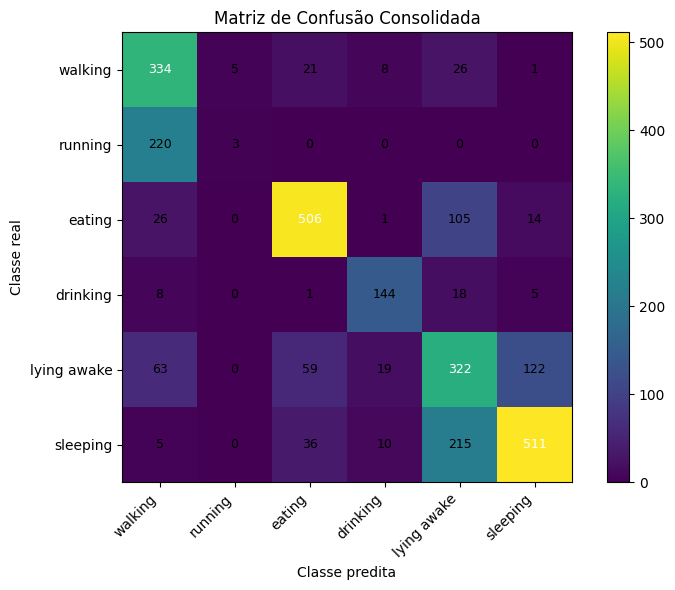

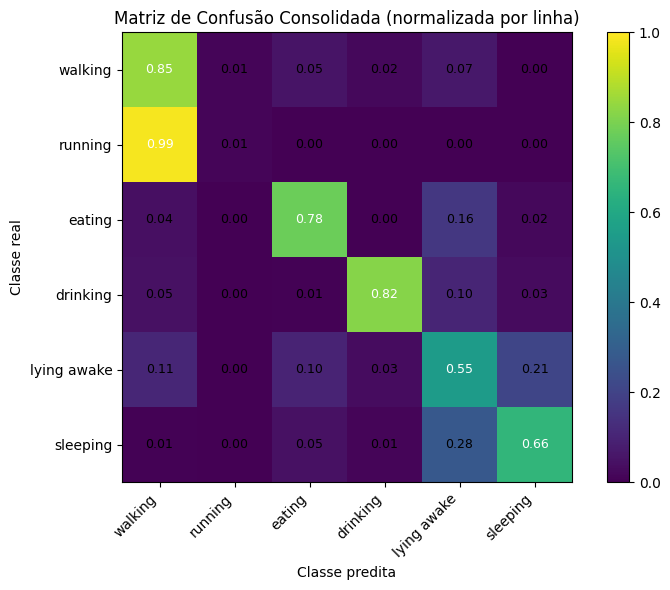


[OK] Tudo salvo em: F:\slowfast_dataset_degcn_aligned_5300xml\vitam_slowfast_runs_6cls_5fold\consolidated_metrics


In [21]:
# =========================================================
# FINAL CONSOLIDATION — ViTAM-SlowFast, SIX CLASSES
# =========================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    average_precision_score,
)
from sklearn.preprocessing import label_binarize

# ---------------------------------------------------------
# PATHS
# ---------------------------------------------------------

RUNS_ROOT = Path(r"F:\slowfast_dataset_degcn_aligned_5300xml\vitam_slowfast_runs_6cls_5fold")
CLASS_JSON = RUNS_ROOT / "class_names.json"

OUTDIR = RUNS_ROOT / "consolidated_metrics"
OUTDIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# LOAD CLASSES
# ---------------------------------------------------------

with open(CLASS_JSON, "r", encoding="utf-8") as f:
    mp = json.load(f)

if "idx_to_class" in mp:
    idx_to_class = {int(k): v for k, v in mp["idx_to_class"].items()}
else:
    idx_to_class = {int(k): v for k, v in mp.items()}

class_names = [idx_to_class[i] for i in sorted(idx_to_class)]
n_classes = len(class_names)

print("Classes:", class_names)

# ---------------------------------------------------------
# LOAD FOLDS
# ---------------------------------------------------------

all_y_true = []
all_y_pred = []
all_probs = []
fold_summary = []

for fold in range(5):
    fold_dir = RUNS_ROOT / f"fold{fold}"
    art_path = fold_dir / "val_artifacts_best.npz"

    if not art_path.exists():
        print(f"[AVISO] Não encontrado: {art_path}")
        continue

    z = np.load(art_path, allow_pickle=True)
    y_true = z["y_true"].astype(int)
    y_pred = z["y_pred"].astype(int)
    probs = z["probs"]

    all_y_true.append(y_true)
    all_y_pred.append(y_pred)
    all_probs.append(probs)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    fold_summary.append({
        "fold": fold,
        "n_samples": len(y_true),
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    })

    print(f"Fold {fold}: n={len(y_true)} | acc={acc:.4f} | macro_f1={macro_f1:.4f}")

if len(all_y_true) == 0:
    raise RuntimeError("Nenhum val_artifacts_best.npz foi encontrado.")

# ---------------------------------------------------------
# CONCATENAR
# ---------------------------------------------------------

y_true_all = np.concatenate(all_y_true)
y_pred_all = np.concatenate(all_y_pred)
probs_all = np.concatenate(all_probs)

print("\nTotal consolidado:")
print("y_true_all:", y_true_all.shape)
print("y_pred_all:", y_pred_all.shape)
print("probs_all :", probs_all.shape)

# ---------------------------------------------------------
# MÉTRICAS GLOBAIS
# ---------------------------------------------------------

acc_all = accuracy_score(y_true_all, y_pred_all)
macro_f1_all = f1_score(y_true_all, y_pred_all, average="macro")
weighted_f1_all = f1_score(y_true_all, y_pred_all, average="weighted")

print("\n=== MÉTRICAS GLOBAIS ===")
print(f"Accuracy    : {acc_all:.6f}")
print(f"Macro-F1    : {macro_f1_all:.6f}")
print(f"Weighted-F1 : {weighted_f1_all:.6f}")

# ---------------------------------------------------------
# CLASSIFICATION REPORT
# ---------------------------------------------------------

report = classification_report(
    y_true_all,
    y_pred_all,
    labels=np.arange(n_classes),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T
report_df.to_csv(OUTDIR / "classification_report_consolidated.csv", encoding="utf-8-sig")

print("\n=== CLASSIFICATION REPORT ===")
display(report_df)

# ---------------------------------------------------------
# CONFUSION MATRIX
# ---------------------------------------------------------

cm = confusion_matrix(y_true_all, y_pred_all, labels=np.arange(n_classes))
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df.to_csv(OUTDIR / "confusion_matrix_consolidated.csv", encoding="utf-8-sig")

print("\n=== MATRIZ DE CONFUSÃO ===")
display(cm_df)

# ---------------------------------------------------------
# CONFUSION MATRIX NORMALIZADA
# ---------------------------------------------------------

cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
cm_norm_df = pd.DataFrame(cm_norm, index=class_names, columns=class_names)
cm_norm_df.to_csv(OUTDIR / "confusion_matrix_normalized.csv", encoding="utf-8-sig")

print("\n=== MATRIZ NORMALIZADA ===")
display(cm_norm_df)

# ---------------------------------------------------------
# AP POR CLASSE + mAP
# ---------------------------------------------------------

Y_bin = label_binarize(y_true_all, classes=np.arange(n_classes))

ap_rows = []
aps = []

for c in range(n_classes):
    if Y_bin[:, c].sum() == 0:
        ap = np.nan
    else:
        ap = average_precision_score(Y_bin[:, c], probs_all[:, c])

    aps.append(ap)
    ap_rows.append({
        "class_idx": c,
        "class_name": class_names[c],
        "AP": ap
    })

ap_df = pd.DataFrame(ap_rows)
ap_df.to_csv(OUTDIR / "average_precision_per_class.csv", index=False, encoding="utf-8-sig")

map_value = np.nanmean(aps)

print("\n=== AP POR CLASSE ===")
display(ap_df)
print(f"\nmAP: {map_value:.6f}")

# ---------------------------------------------------------
# RESUMO POR FOLD
# ---------------------------------------------------------

fold_summary_df = pd.DataFrame(fold_summary)
fold_summary_df.to_csv(OUTDIR / "fold_summary.csv", index=False, encoding="utf-8-sig")

print("\n=== RESUMO POR FOLD ===")
display(fold_summary_df)

# ---------------------------------------------------------
# RESUMO GLOBAL
# ---------------------------------------------------------

global_summary = pd.DataFrame([{
    "accuracy": acc_all,
    "macro_f1": macro_f1_all,
    "weighted_f1": weighted_f1_all,
    "mAP": map_value,
    **{f"AP_{row['class_name']}": row["AP"] for _, row in ap_df.iterrows()}
}])

global_summary.to_csv(OUTDIR / "global_summary.csv", index=False, encoding="utf-8-sig")

print("\n=== RESUMO GLOBAL ===")
display(global_summary)

# ---------------------------------------------------------
# PLOTS
# ---------------------------------------------------------

ticks = np.arange(n_classes)

# matriz absoluta
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Matriz de Confusão Consolidada")
plt.colorbar()
plt.xticks(ticks, class_names, rotation=45, ha="right")
plt.yticks(ticks, class_names)

thresh = cm.max() / 2 if cm.max() > 0 else 0.5
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, f"{cm[i, j]}",
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black",
            fontsize=9
        )

plt.ylabel("Classe real")
plt.xlabel("Classe predita")
plt.tight_layout()
plt.savefig(OUTDIR / "confusion_matrix_consolidated.png", dpi=200, bbox_inches="tight")
plt.show()

# matriz normalizada
plt.figure(figsize=(8, 6))
plt.imshow(cm_norm, interpolation="nearest", vmin=0, vmax=1)
plt.title("Matriz de Confusão Consolidada (normalizada por linha)")
plt.colorbar()
plt.xticks(ticks, class_names, rotation=45, ha="right")
plt.yticks(ticks, class_names)

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        plt.text(
            j, i, f"{cm_norm[i, j]:.2f}",
            ha="center", va="center",
            color="white" if cm_norm[i, j] > 0.5 else "black",
            fontsize=9
        )

plt.ylabel("Classe real")
plt.xlabel("Classe predita")
plt.tight_layout()
plt.savefig(OUTDIR / "confusion_matrix_normalized.png", dpi=200, bbox_inches="tight")
plt.show()

print("\n[OK] Tudo salvo em:", OUTDIR)

## Reproducibility step: Benchmark vitam slowfast

This cell is part of the ViTAM-SlowFast experimental workflow. It prepares inputs, executes model-related processing, or generates artifacts required for training, evaluation, benchmarking, or result consolidation. Keeping this step documented helps make the notebook easier to audit and rerun when reproducing the reported experiments.

In [ ]:
# Benchmark vitam slowfast

## Generic inference benchmarking utility

This cell defines a reusable benchmarking function for measuring inference latency and GPU memory usage. The function performs warm-up iterations to stabilize GPU execution, synchronizes CUDA operations when necessary, records multiple timed forward passes, and summarizes the average inference time.

The same benchmarking routine can be reused for different models, enabling a fairer comparison between ViTAM-SlowFast, SlowFast, skeleton-based networks, and other baselines.

In [25]:
# =========================================================
# GENERIC INFERENCE BENCHMARK
# =========================================================

import torch
import time
import numpy as np

def benchmark_inference(
    model,
    make_input_fn,
    device="cuda",
    n_warmup=20,
    n_runs=100,
    model_name="model"
):
    model.eval()
    model.to(device)

    # clear GPU memory
    if device == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    # -----------------------------------------------------
    # WARM-UP (very important)
    # -----------------------------------------------------
    with torch.no_grad():
        for _ in range(n_warmup):
            x = make_input_fn()
            _ = model(x)

    # -----------------------------------------------------
    # measurement
    # -----------------------------------------------------
    times = []

    with torch.no_grad():
        for _ in range(n_runs):
            x = make_input_fn()

            if device == "cuda":
                torch.cuda.synchronize()

            t0 = time.perf_counter()
            _ = model(x)

            if device == "cuda":
                torch.cuda.synchronize()

            t1 = time.perf_counter()
            times.append(t1 - t0)

    times = np.array(times)

    # -----------------------------------------------------
    # MÉTRICAS
    # -----------------------------------------------------
    tempo_medio_batch = times.mean()
    desvio_batch = times.std()

    # inferir batch size automaticamente
    sample_input = make_input_fn()
    if isinstance(sample_input, list):
        batch_size = sample_input[0].shape[0]
    else:
        batch_size = sample_input.shape[0]

    tempo_amostra = tempo_medio_batch / batch_size

    fps = 1.0 / tempo_amostra

    if device == "cuda":
        mem = torch.cuda.max_memory_allocated() / 1024**2
    else:
        mem = 0.0

    n_params = sum(p.numel() for p in model.parameters())

    # -----------------------------------------------------
    # PRINT
    # -----------------------------------------------------
    print(f"\n=== Benchmark: {model_name} ===")
    print(f"device: {device}")
    print(f"tempo_medio_batch_s: {tempo_medio_batch:.6f}")
    print(f"desvio_batch_s: {desvio_batch:.6f}")
    print(f"tempo_medio_amostra_s: {tempo_amostra:.6f}")
    print(f"tempo_medio_amostra_ms: {tempo_amostra*1000:.6f}")
    print(f"desvio_amostra_ms: {(desvio_batch/batch_size)*1000:.6f}")
    print(f"fps_inferencia: {fps:.6f}")
    print(f"memoria_max_gpu_mb: {mem:.6f}")
    print(f"n_parametros: {n_params}")

    return {
        "tempo_batch_s": tempo_medio_batch,
        "tempo_amostra_ms": tempo_amostra * 1000,
        "fps": fps,
        "memoria_mb": mem,
        "n_parametros": n_params,
    }

## ViTAM-SlowFast inference benchmark

This cell applies the generic benchmarking routine to the adapted ViTAM-SlowFast model. Synthetic slow and fast pathway inputs are generated with the expected tensor shapes, and repeated forward passes are timed.

The resulting latency estimate supports the computational-efficiency analysis of the method, especially when comparing RGB-based models against lighter skeleton-based alternatives.

In [27]:
# =========================================================
# BENCHMARK ViTAM-SlowFast
# =========================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model_vitam = ViTAMSlowFastAdapted(num_classes=6).to(DEVICE)

# use a small batch for benchmarking
BATCH = 2

def make_input_vitam():
    slow = torch.randn(BATCH, 3, 8, 224, 224).to(DEVICE)
    fast = torch.randn(BATCH, 3, 32, 224, 224).to(DEVICE)
    return [slow, fast]

result_vitam = benchmark_inference(
    model=model_vitam,
    make_input_fn=make_input_vitam,
    device=DEVICE,
    n_warmup=20,
    n_runs=100,
    model_name="ViTAM-SlowFast"
)

C:\Users\pedro\anaconda3\envs\vision_pose_cuda\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



=== Benchmark: ViTAM-SlowFast ===
device: cuda
tempo_medio_batch_s: 0.027367
desvio_batch_s: 0.013112
tempo_medio_amostra_s: 0.013683
tempo_medio_amostra_ms: 13.683401
desvio_amostra_ms: 6.556143
fps_inferencia: 73.081246
memoria_max_gpu_mb: 491.206543
n_parametros: 5296310


# ViTAM-SlowFast Training for the Four-Class Scenario

## Adapted ViTAM-SlowFast architecture

This cell implements the adapted ViTAM-SlowFast model used for pig behavior classification. The model follows the SlowFast idea of processing the same clip through two temporal pathways: a slow pathway for lower-frequency semantic information and a fast pathway for higher-frequency motion cues. A simplified Temporal Adaptive Module is added to reweight temporal features dynamically, allowing the network to emphasize frames that are more informative for behavior discrimination.

The architecture is intentionally compact compared with large video backbones. This makes it suitable as a controlled visual baseline when comparing RGB-based temporal representations against skeleton-based methods such as DeGCN and KP-TCN.

In [42]:
# =========================================================
# ADAPTED ViTAM-SlowFast — FOUR CLASSES, FIVE FOLDS
# =========================================================

from pathlib import Path
import json
import time
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# =========================================================
# DATASET
# =========================================================

class PigSlowFastDataset(Dataset):
    def __init__(self, csv_path, src_frames=15, fast_frames=32, slow_frames=8, img_size=224):
        self.df = pd.read_csv(csv_path).reset_index(drop=True)
        self.src_frames = src_frames
        self.fast_frames = fast_frames
        self.slow_frames = slow_frames
        self.img_size = img_size

        self.fast_idx = np.linspace(0, self.src_frames - 1, self.fast_frames).round().astype(int)
        self.slow_idx = np.linspace(0, self.fast_frames - 1, self.slow_frames).round().astype(int)

    def __len__(self):
        return len(self.df)

    def _load_src_clip(self, clip_dir):
        frames = []
        clip_dir = Path(clip_dir)

        for t in range(self.src_frames):
            p = clip_dir / f"img_{t:03d}.jpg"
            img = cv2.imread(str(p))
            if img is None:
                raise ValueError(f"Erro ao ler: {p}")

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)
            img = img.astype(np.float32) / 255.0

            mean = np.array([0.45, 0.45, 0.45], dtype=np.float32)
            std = np.array([0.225, 0.225, 0.225], dtype=np.float32)
            img = (img - mean) / std

            img = np.transpose(img, (2, 0, 1))
            frames.append(img)

        return np.stack(frames, axis=0)  # (T, C, H, W)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        src_clip = self._load_src_clip(row["clip_dir"])

        fast = src_clip[self.fast_idx]            # (32, C, H, W)
        fast = np.transpose(fast, (1, 0, 2, 3))  # (C, 32, H, W)
        slow = fast[:, self.slow_idx, :, :]      # (C, 8, H, W)

        slow = torch.tensor(slow, dtype=torch.float32)
        fast = torch.tensor(fast, dtype=torch.float32)
        y = int(row["label_idx"])

        meta = {
            "clip_name": row["clip_name"],
            "clip_idx": int(row["clip_idx"]),
            "track_id": int(row["track_id"]),
            "start_frame": int(row["start_frame"]),
            "label_name": row["label_name"],
        }

        return [slow, fast], y, meta


def collate_fn(batch):
    slow = torch.stack([b[0][0] for b in batch], dim=0)
    fast = torch.stack([b[0][1] for b in batch], dim=0)
    y = torch.tensor([b[1] for b in batch], dtype=torch.long)
    meta = [b[2] for b in batch]
    return [slow, fast], y, meta

print("✅ Dataset pronto")

# =========================================================
# MODELO
# =========================================================

class TemporalAdaptiveModule(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.fc1 = nn.Linear(channels, hidden)
        self.fc2 = nn.Linear(hidden, channels)
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x):
        xs = x.mean(dim=[3, 4])                  # [B, C, T]
        local_att = torch.sigmoid(self.conv1(xs))
        local_att = local_att.unsqueeze(-1).unsqueeze(-1)

        xg = xs.mean(dim=2)                      # [B, C]
        g = F.relu(self.fc1(xg))
        g = torch.sigmoid(self.fc2(g))
        g = g.unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)

        return x * local_att * g


class FastPathway(nn.Module):
    def __init__(self, in_channels=3, base_channels=24, out_dim=128):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv3d(in_channels, base_channels, kernel_size=(3, 7, 7), stride=(1, 2, 2), padding=(1, 3, 3)),
            nn.BatchNorm3d(base_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(1, 3, 3), stride=(1, 2, 2), padding=(0, 1, 1)),
        )

        self.block1 = nn.Sequential(
            nn.Conv3d(base_channels, 48, kernel_size=3, padding=1),
            nn.BatchNorm3d(48),
            nn.ReLU(inplace=True),
        )
        self.tam1 = TemporalAdaptiveModule(48)

        self.block2 = nn.Sequential(
            nn.Conv3d(48, 96, kernel_size=3, stride=(1, 2, 2), padding=1),
            nn.BatchNorm3d(96),
            nn.ReLU(inplace=True),
        )
        self.tam2 = TemporalAdaptiveModule(96)

        self.block3 = nn.Sequential(
            nn.Conv3d(96, out_dim, kernel_size=3, stride=(1, 2, 2), padding=1),
            nn.BatchNorm3d(out_dim),
            nn.ReLU(inplace=True),
        )
        self.tam3 = TemporalAdaptiveModule(out_dim)

        self.pool = nn.AdaptiveAvgPool3d((1, 1, 1))

    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.tam1(x)
        x = self.block2(x)
        x = self.tam2(x)
        x = self.block3(x)
        x = self.tam3(x)
        feat_map = x
        x = self.pool(x).flatten(1)
        return x, feat_map


class PatchEmbed3D(nn.Module):
    def __init__(self, in_channels=3, embed_dim=128, patch_size=(2, 16, 16)):
        super().__init__()
        self.proj = nn.Conv3d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        b, e, t, h, w = x.shape
        x = x.flatten(2).transpose(1, 2)
        return x, (t, h, w)


class SlowPathwayViT(nn.Module):
    def __init__(self, in_channels=3, embed_dim=128, depth=2, num_heads=4, mlp_ratio=4.0):
        super().__init__()

        self.patch_embed = PatchEmbed3D(in_channels, embed_dim, patch_size=(2, 16, 16))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            dropout=0.1,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        tokens, shape_3d = self.patch_embed(x)
        tokens = self.encoder(tokens)
        tokens = self.norm(tokens)
        feat = tokens.mean(dim=1)
        return feat, tokens, shape_3d


class LateralFusion(nn.Module):
    def __init__(self, fast_dim=128, slow_dim=128, out_dim=128):
        super().__init__()
        self.fast_proj = nn.Linear(fast_dim, out_dim)
        self.slow_proj = nn.Linear(slow_dim, out_dim)

    def forward(self, fast_feat, slow_feat):
        f = self.fast_proj(fast_feat)
        s = self.slow_proj(slow_feat)
        return torch.cat([s, f], dim=1)


class ViTAMSlowFastAdapted(nn.Module):
    def __init__(self, num_classes=4, slow_dim=128, fast_dim=128):
        super().__init__()

        self.slow_path = SlowPathwayViT(
            in_channels=3,
            embed_dim=slow_dim,
            depth=2,
            num_heads=4,
            mlp_ratio=4.0
        )

        self.fast_path = FastPathway(
            in_channels=3,
            base_channels=24,
            out_dim=fast_dim
        )

        self.fusion = LateralFusion(
            fast_dim=fast_dim,
            slow_dim=slow_dim,
            out_dim=128
        )

        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        slow_x, fast_x = x
        slow_feat, _, _ = self.slow_path(slow_x)
        fast_feat, _ = self.fast_path(fast_x)
        fused = self.fusion(fast_feat, slow_feat)
        logits = self.classifier(fused)
        return logits

print("✅ Modelo pronto")

# =========================================================
# CONFIG DE TREINO
# =========================================================

ROOT = Path(r"F:\slowfast_dataset_degcn_aligned_5300xml\merged_4classes")
FOLDS_DIR = ROOT / "folds_aligned"
SAVE_ROOT = ROOT / "vitam_slowfast_runs_4cls_5fold"
SAVE_ROOT.mkdir(parents=True, exist_ok=True)

LABELS_MAP = ROOT / "labels_map_4cls.json"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16
NUM_WORKERS = 0
EPOCHS = 50
LR = 1e-4
WEIGHT_DECAY = 1e-4

IMG_SIZE = 160
SRC_FRAMES = 15
FAST_FRAMES = 32
SLOW_FRAMES = 8

print("DEVICE:", DEVICE)

with open(LABELS_MAP, "r", encoding="utf-8") as f:
    mp = json.load(f)

if "idx_to_class" in mp:
    idx_to_class = {int(k): v for k, v in mp["idx_to_class"].items()}
elif "class_to_idx" in mp:
    idx_to_class = {int(v): k for k, v in mp["class_to_idx"].items()}
else:
    idx_to_class = {int(k): v for k, v in mp.items()}

class_names = [idx_to_class[i] for i in sorted(idx_to_class)]
NUM_CLASSES = len(class_names)

print("Classes:", class_names)

with open(SAVE_ROOT / "class_names.json", "w", encoding="utf-8") as f:
    json.dump({"idx_to_class": {str(i): c for i, c in enumerate(class_names)}}, f, ensure_ascii=False, indent=2)

# =========================================================
# LOOP 5 FOLDS
# =========================================================

global_summary = []

for fold in range(5):
    print("\n" + "=" * 70)
    print(f"FOLD {fold}")
    print("=" * 70)

    csv_train = FOLDS_DIR / f"fold{fold}_train.csv"
    csv_val   = FOLDS_DIR / f"fold{fold}_val.csv"

    ds_train = PigSlowFastDataset(csv_train, SRC_FRAMES, FAST_FRAMES, SLOW_FRAMES, IMG_SIZE)
    ds_val   = PigSlowFastDataset(csv_val,   SRC_FRAMES, FAST_FRAMES, SLOW_FRAMES, IMG_SIZE)

    dl_train = DataLoader(
        ds_train, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn
    )
    dl_val = DataLoader(
        ds_val, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn
    )

    print("Train:", len(ds_train))
    print("Val  :", len(ds_val))

    df_train = pd.read_csv(csv_train)
    counts = df_train["label_idx"].value_counts().sort_index()

    weights = np.ones(NUM_CLASSES, dtype=np.float32)
    for c in range(NUM_CLASSES):
        n = counts.get(c, 1)
        weights[c] = len(df_train) / (NUM_CLASSES * n)

    weights = torch.tensor(weights, dtype=torch.float32, device=DEVICE)
    print("Class weights:", weights)

    model = ViTAMSlowFastAdapted(num_classes=NUM_CLASSES).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=3
    )

    best_macro_f1 = -1.0
    best_epoch = -1
    history = []

    fold_dir = SAVE_ROOT / f"fold{fold}"
    fold_dir.mkdir(parents=True, exist_ok=True)

    for epoch in range(EPOCHS):
        t0 = time.time()
        print(f"\n[FOLD {fold}] EPOCH {epoch+1}/{EPOCHS}")

        model.train()
        train_losses = []

        for i, (x, y, _) in enumerate(dl_train):
            if i % 10 == 0:
                print(f"[TRAIN] batch {i}/{len(dl_train)}")

            x = [t.to(DEVICE, non_blocking=True) for t in x]
            y = y.to(DEVICE, non_blocking=True)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses)) if len(train_losses) > 0 else np.nan

        model.eval()
        y_true = []
        y_pred = []
        probs_all = []
        meta_all = []
        val_losses = []

        with torch.no_grad():
            for i, (x, y, meta_batch) in enumerate(dl_val):
                if i % 10 == 0:
                    print(f"[VAL] batch {i}/{len(dl_val)}")

                x = [t.to(DEVICE, non_blocking=True) for t in x]
                y_gpu = y.to(DEVICE, non_blocking=True)

                logits = model(x)
                loss_val = criterion(logits, y_gpu)
                val_losses.append(loss_val.item())

                probs = torch.softmax(logits, dim=1).cpu().numpy()
                pred = probs.argmax(axis=1)

                y_true.append(y.numpy())
                y_pred.append(pred)
                probs_all.append(probs)
                meta_all.extend(meta_batch)

        y_true = np.concatenate(y_true)
        y_pred = np.concatenate(y_pred)
        probs_all = np.concatenate(probs_all)

        acc = accuracy_score(y_true, y_pred)
        macro_f1 = f1_score(y_true, y_pred, average="macro")
        weighted_f1 = f1_score(y_true, y_pred, average="weighted")
        val_loss = float(np.mean(val_losses)) if len(val_losses) > 0 else np.nan
        epoch_time = time.time() - t0

        row = {
            "fold": fold,
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_acc": acc,
            "val_macro_f1": macro_f1,
            "val_weighted_f1": weighted_f1,
            "lr": optimizer.param_groups[0]["lr"],
            "epoch_time_sec": epoch_time,
        }
        history.append(row)

        print(
            f"[FOLD {fold}] epoch={epoch+1} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"acc={acc:.4f} | "
            f"macro_f1={macro_f1:.4f} | "
            f"weighted_f1={weighted_f1:.4f} | "
            f"time={epoch_time:.1f}s"
        )

        scheduler.step(macro_f1)

        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_epoch = epoch + 1

            print(f"🔥 [FOLD {fold}] Novo melhor modelo na época {best_epoch} (macro-F1={best_macro_f1:.4f})")

            torch.save(model.state_dict(), fold_dir / "best.pt")

            np.savez_compressed(
                fold_dir / "val_artifacts_best.npz",
                y_true=y_true,
                y_pred=y_pred,
                probs=probs_all
            )

            pd.DataFrame(meta_all).to_csv(
                fold_dir / "meta_val_best.csv",
                index=False,
                encoding="utf-8-sig"
            )

            cm = confusion_matrix(y_true, y_pred, labels=np.arange(NUM_CLASSES))
            pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(
                fold_dir / "confusion_matrix_best.csv",
                encoding="utf-8-sig"
            )

            rep = classification_report(
                y_true, y_pred,
                labels=np.arange(NUM_CLASSES),
                target_names=class_names,
                output_dict=True,
                zero_division=0
            )
            pd.DataFrame(rep).T.to_csv(
                fold_dir / "classification_report_best.csv",
                encoding="utf-8-sig"
            )

            with open(fold_dir / "summary_best.json", "w", encoding="utf-8") as f:
                json.dump(
                    {
                        "fold": fold,
                        "best_epoch": best_epoch,
                        "best_val_acc": acc,
                        "best_val_macro_f1": macro_f1,
                        "best_val_weighted_f1": weighted_f1,
                        "n_train": len(ds_train),
                        "n_val": len(ds_val),
                        "class_names": class_names,
                    },
                    f,
                    ensure_ascii=False,
                    indent=2
                )

        pd.DataFrame(history).to_csv(
            fold_dir / "history.csv",
            index=False,
            encoding="utf-8-sig"
        )

    global_summary.append({
        "fold": fold,
        "best_epoch": best_epoch,
        "best_macro_f1": best_macro_f1,
        "n_train": len(ds_train),
        "n_val": len(ds_val),
    })

global_summary_df = pd.DataFrame(global_summary)
global_summary_df.to_csv(
    SAVE_ROOT / "global_summary_folds.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n[OK] TREINAMENTO ViTAM-SlowFast 4 CLASSES FINALIZADO")
display(global_summary_df)
print("Artefatos salvos em:", SAVE_ROOT)

✅ Dataset pronto
✅ Modelo pronto
DEVICE: cuda
Classes: ['deslocando', 'eating', 'drinking', 'deitado']

FOLD 0
Train: 2430
Val  : 378
Class weights: tensor([1.1355, 1.0492, 3.5735, 0.5301], device='cuda:0')

[FOLD 0] EPOCH 1/50


C:\Users\pedro\anaconda3\envs\vision_pose_cuda\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[TRAIN] batch 0/152
[TRAIN] batch 10/152
[TRAIN] batch 20/152
[TRAIN] batch 30/152
[TRAIN] batch 40/152
[TRAIN] batch 50/152
[TRAIN] batch 60/152
[TRAIN] batch 70/152
[TRAIN] batch 80/152
[TRAIN] batch 90/152
[TRAIN] batch 100/152
[TRAIN] batch 110/152
[TRAIN] batch 120/152
[TRAIN] batch 130/152
[TRAIN] batch 140/152
[TRAIN] batch 150/152
[VAL] batch 0/24
[VAL] batch 10/24
[VAL] batch 20/24
[FOLD 0] epoch=1 | train_loss=0.9549 | val_loss=0.9619 | acc=0.5582 | macro_f1=0.4674 | weighted_f1=0.5468 | time=96.4s
🔥 [FOLD 0] Novo melhor modelo na época 1 (macro-F1=0.4674)

[FOLD 0] EPOCH 2/50
[TRAIN] batch 0/152
[TRAIN] batch 10/152
[TRAIN] batch 20/152
[TRAIN] batch 30/152
[TRAIN] batch 40/152
[TRAIN] batch 50/152
[TRAIN] batch 60/152
[TRAIN] batch 70/152
[TRAIN] batch 80/152
[TRAIN] batch 90/152
[TRAIN] batch 100/152
[TRAIN] batch 110/152
[TRAIN] batch 120/152
[TRAIN] batch 130/152
[TRAIN] batch 140/152
[TRAIN] batch 150/152
[VAL] batch 0/24
[VAL] batch 10/24
[VAL] batch 20/24
[FOLD 0] epo

C:\Users\pedro\anaconda3\envs\vision_pose_cuda\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[TRAIN] batch 0/145
[TRAIN] batch 10/145
[TRAIN] batch 20/145
[TRAIN] batch 30/145
[TRAIN] batch 40/145
[TRAIN] batch 50/145
[TRAIN] batch 60/145
[TRAIN] batch 70/145
[TRAIN] batch 80/145
[TRAIN] batch 90/145
[TRAIN] batch 100/145
[TRAIN] batch 110/145
[TRAIN] batch 120/145
[TRAIN] batch 130/145
[TRAIN] batch 140/145
[VAL] batch 0/31
[VAL] batch 10/31
[VAL] batch 20/31
[VAL] batch 30/31
[FOLD 1] epoch=1 | train_loss=0.9196 | val_loss=0.7227 | acc=0.5633 | macro_f1=0.5206 | weighted_f1=0.5471 | time=93.3s
🔥 [FOLD 1] Novo melhor modelo na época 1 (macro-F1=0.5206)

[FOLD 1] EPOCH 2/50
[TRAIN] batch 0/145
[TRAIN] batch 10/145
[TRAIN] batch 20/145
[TRAIN] batch 30/145
[TRAIN] batch 40/145
[TRAIN] batch 50/145
[TRAIN] batch 60/145
[TRAIN] batch 70/145
[TRAIN] batch 80/145
[TRAIN] batch 90/145
[TRAIN] batch 100/145
[TRAIN] batch 110/145
[TRAIN] batch 120/145
[TRAIN] batch 130/145
[TRAIN] batch 140/145
[VAL] batch 0/31
[VAL] batch 10/31
[VAL] batch 20/31
[VAL] batch 30/31
[FOLD 1] epoch=2 | t

...

[TRAIN] batch 0/130
[TRAIN] batch 10/130
[TRAIN] batch 20/130
[TRAIN] batch 30/130
[TRAIN] batch 40/130
[TRAIN] batch 50/130
[TRAIN] batch 60/130
[TRAIN] batch 70/130
[TRAIN] batch 80/130
[TRAIN] batch 90/130
[TRAIN] batch 100/130
[TRAIN] batch 110/130
[TRAIN] batch 120/130
[VAL] batch 0/47
[VAL] batch 10/47
[VAL] batch 20/47
[VAL] batch 30/47
[VAL] batch 40/47
[FOLD 3] epoch=1 | train_loss=1.0352 | val_loss=0.4972 | acc=0.6545 | macro_f1=0.6407 | weighted_f1=0.6317 | time=90.7s
🔥 [FOLD 3] Novo melhor modelo na época 1 (macro-F1=0.6407)

[FOLD 3] EPOCH 2/50
[TRAIN] batch 0/130
[TRAIN] batch 10/130
[TRAIN] batch 20/130
[TRAIN] batch 30/130
[TRAIN] batch 40/130
[TRAIN] batch 50/130
[TRAIN] batch 60/130
[TRAIN] batch 70/130
[TRAIN] batch 80/130
[TRAIN] batch 90/130
[TRAIN] batch 100/130
[TRAIN] batch 110/130
[TRAIN] batch 120/130
[VAL] batch 0/47
[VAL] batch 10/47
[VAL] batch 20/47
[VAL] batch 30/47
[VAL] batch 40/47
[FOLD 3] epoch=2 | train_loss=0.6259 | val_loss=0.3977 | acc=0.8537 | ma

C:\Users\pedro\anaconda3\envs\vision_pose_cuda\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[TRAIN] batch 0/138
[TRAIN] batch 10/138
[TRAIN] batch 20/138
[TRAIN] batch 30/138
[TRAIN] batch 40/138
[TRAIN] batch 50/138
[TRAIN] batch 60/138
[TRAIN] batch 70/138
[TRAIN] batch 80/138
[TRAIN] batch 90/138
[TRAIN] batch 100/138
[TRAIN] batch 110/138
[TRAIN] batch 120/138
[TRAIN] batch 130/138
[VAL] batch 0/39
[VAL] batch 10/39
[VAL] batch 20/39
[VAL] batch 30/39
[FOLD 4] epoch=1 | train_loss=1.1138 | val_loss=1.1218 | acc=0.5668 | macro_f1=0.3801 | weighted_f1=0.6439 | time=90.7s
🔥 [FOLD 4] Novo melhor modelo na época 1 (macro-F1=0.3801)

[FOLD 4] EPOCH 2/50
[TRAIN] batch 0/138
[TRAIN] batch 10/138
[TRAIN] batch 20/138
[TRAIN] batch 30/138
[TRAIN] batch 40/138
[TRAIN] batch 50/138
[TRAIN] batch 60/138
[TRAIN] batch 70/138
[TRAIN] batch 80/138
[TRAIN] batch 90/138
[TRAIN] batch 100/138
[TRAIN] batch 110/138
[TRAIN] batch 120/138
[TRAIN] batch 130/138
[VAL] batch 0/39
[VAL] batch 10/39
[VAL] batch 20/39
[VAL] batch 30/39
[FOLD 4] epoch=2 | train_loss=0.7587 | val_loss=0.5445 | acc=0.7

,fold,best_epoch,best_macro_f1,n_train,n_val
0,0,12,0.638454,2430,378
1,1,21,0.814891,2318,490
2,2,37,0.808681,2220,588
3,3,8,0.860176,2070,738
4,4,5,0.548270,2194,614


Artefatos salvos em: F:\slowfast_dataset_degcn_aligned_5300xml\merged_4classes\vitam_slowfast_runs_4cls_5fold


## Complete ViTAM-SlowFast benchmarking block

This cell provides a complete standalone benchmark for the ViTAM-SlowFast architecture. It creates synthetic slow and fast pathway inputs, performs warm-up runs, measures synchronized inference time, and reports timing statistics.

This benchmark is useful when the notebook is executed independently from the earlier generic benchmarking function or when a direct latency estimate is needed for the final experimental comparison.

In [44]:
# =========================================================
# ViTAM-SlowFast BENCHMARK — complete version
# =========================================================

import torch
import time
import numpy as np

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model_vitam = ViTAMSlowFastAdapted(num_classes=6).to(DEVICE)
model_vitam.eval()

BATCH = 2

def make_input_vitam():
    slow = torch.randn(BATCH, 3, 8, 224, 224).to(DEVICE)
    fast = torch.randn(BATCH, 3, 32, 224, 224).to(DEVICE)
    return [slow, fast]

def benchmark(model, make_input_fn, n_warmup=20, n_runs=100):
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    # warmup
    with torch.no_grad():
        for _ in range(n_warmup):
            _ = model(make_input_fn())

    times = []

    with torch.no_grad():
        for _ in range(n_runs):
            x = make_input_fn()

            if DEVICE == "cuda":
                torch.cuda.synchronize()

            t0 = time.perf_counter()
            _ = model(x)

            if DEVICE == "cuda":
                torch.cuda.synchronize()

            t1 = time.perf_counter()
            times.append(t1 - t0)

    times = np.array(times)

    batch_time = times.mean()
    batch_std = times.std()

    sample_time = batch_time / BATCH
    fps = 1.0 / sample_time

    mem = torch.cuda.max_memory_allocated() / 1024**2 if DEVICE == "cuda" else 0
    n_params = sum(p.numel() for p in model.parameters())

    print("\n=== ViTAM-SlowFast Benchmark ===")
    print(f"device: {DEVICE}")
    print(f"tempo_medio_batch_s: {batch_time:.6f}")
    print(f"desvio_batch_s: {batch_std:.6f}")
    print(f"tempo_medio_amostra_s: {sample_time:.6f}")
    print(f"tempo_medio_amostra_ms: {sample_time*1000:.6f}")
    print(f"desvio_amostra_ms: {(batch_std/BATCH)*1000:.6f}")
    print(f"fps_inferencia: {fps:.6f}")
    print(f"memoria_max_gpu_mb: {mem:.6f}")
    print(f"n_parametros: {n_params}")

benchmark(model_vitam, make_input_vitam)

C:\Users\pedro\anaconda3\envs\vision_pose_cuda\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



=== ViTAM-SlowFast Benchmark ===
device: cuda
tempo_medio_batch_s: 0.022534
desvio_batch_s: 0.002261
tempo_medio_amostra_s: 0.011267
tempo_medio_amostra_ms: 11.267242
desvio_amostra_ms: 1.130480
fps_inferencia: 88.752860
memoria_max_gpu_mb: 1837.891113
n_parametros: 1257274


## Consolidation of four-class ViTAM-SlowFast results

This cell consolidates the validation artifacts from the four-class ViTAM-SlowFast experiment. It loads prediction files from each fold, combines them into a single evaluation set, computes global metrics, and generates confusion matrices and summary tables.

The output is used to compare ViTAM-SlowFast against the skeleton-based and classical baselines in the aggregated behavior-label setting.

Classes: ['deslocando', 'eating', 'drinking', 'deitado']
Fold 0: n=378 | acc=0.7116 | macro_f1=0.6385
Fold 1: n=490 | acc=0.8959 | macro_f1=0.8149
Fold 2: n=588 | acc=0.9099 | macro_f1=0.8087
Fold 3: n=738 | acc=0.9079 | macro_f1=0.8602
Fold 4: n=614 | acc=0.8648 | macro_f1=0.5483

Total consolidado:
y_true_all: (2808,)
y_pred_all: (2808,)
probs_all : (2808, 4)

=== MÉTRICAS GLOBAIS ===
Accuracy    : 0.870370
Macro-F1    : 0.852131
Weighted-F1 : 0.870902

=== CLASSIFICATION REPORT ===


,precision,recall,f1-score,support
deslocando,0.865237,0.914239,0.889064,618.00000
eating,0.820029,0.866564,0.842655,652.00000
drinking,0.759162,0.823864,0.790191,176.00000
deitado,0.916863,0.858297,0.886614,1362.00000
accuracy,0.870370,0.870370,0.870370,0.87037
macro avg,0.840323,0.865741,0.852131,2808.00000
weighted avg,0.873132,0.870370,0.870902,2808.00000



=== MATRIZ DE CONFUSÃO ===


,deslocando,eating,drinking,deitado
deslocando,565,24,8,21
eating,26,565,1,60
drinking,5,1,145,25
deitado,57,99,37,1169



=== MATRIZ NORMALIZADA ===


...

,class_idx,class_name,AP
0,0,deslocando,0.905765
1,1,eating,0.882576
2,2,drinking,0.828081
3,3,deitado,0.935790



mAP: 0.888053

=== RESUMO POR FOLD ===


,fold,n_samples,accuracy,macro_f1,weighted_f1
0,0,378,0.711640,0.638454,0.724529
1,1,490,0.895918,0.814891,0.896827
2,2,588,0.909864,0.808681,0.909052
3,3,738,0.907859,0.860176,0.907602
4,4,614,0.864821,0.548270,0.849105



=== RESUMO GLOBAL ===


,accuracy,macro_f1,weighted_f1,mAP,AP_deslocando,AP_eating,AP_drinking,AP_deitado
0,0.87037,0.852131,0.870902,0.888053,0.905765,0.882576,0.828081,0.93579


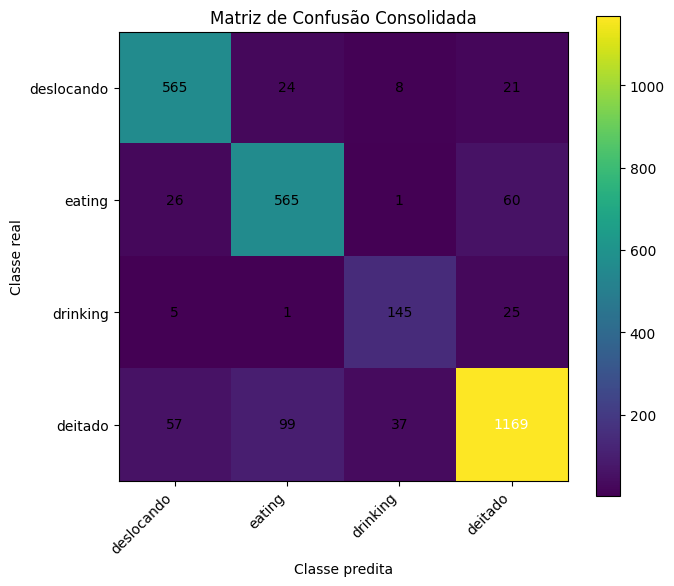

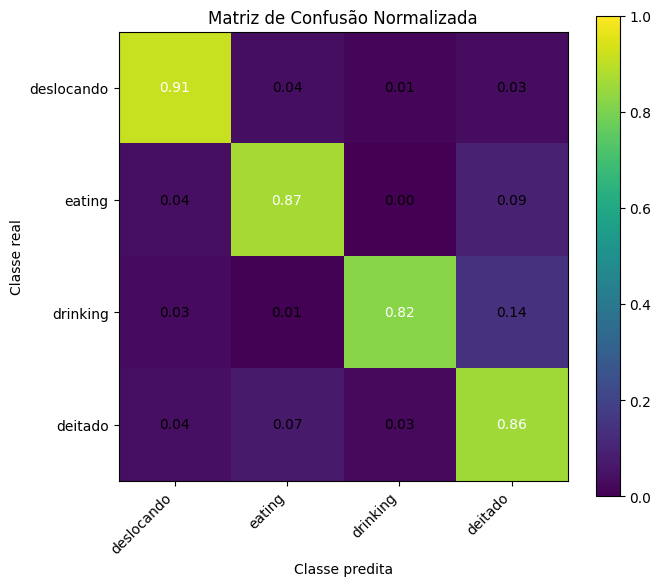


[OK] Consolidação 4 classes finalizada.
Arquivos salvos em: F:\slowfast_dataset_degcn_aligned_5300xml\merged_4classes\vitam_slowfast_runs_4cls_5fold\consolidated_metrics


In [52]:
# =========================================================
# CONSOLIDAÇÃO FINAL — ViTAM-SlowFast 4 CLASSES
# CORRECT PATH
# =========================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    average_precision_score,
)
from sklearn.preprocessing import label_binarize

# ---------------------------------------------------------
# PATHS
# ---------------------------------------------------------

RUNS_ROOT = Path(r"F:\slowfast_dataset_degcn_aligned_5300xml\merged_4classes\vitam_slowfast_runs_4cls_5fold")
OUTDIR = RUNS_ROOT / "consolidated_metrics"
OUTDIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# CLASSES
# ---------------------------------------------------------

class_names = ["deslocando", "eating", "drinking", "deitado"]
n_classes = len(class_names)

print("Classes:", class_names)

# ---------------------------------------------------------
# LOAD FOLD ARTIFACTS
# ---------------------------------------------------------

all_y_true = []
all_y_pred = []
all_probs = []
fold_summary = []

for fold in range(5):
    fold_dir = RUNS_ROOT / f"fold{fold}"
    art_path = fold_dir / "val_artifacts_best.npz"

    if not art_path.exists():
        print(f"[AVISO] Não encontrado: {art_path}")
        continue

    z = np.load(art_path, allow_pickle=True)

    y_true = z["y_true"].astype(int)
    y_pred = z["y_pred"].astype(int)
    probs = z["probs"]

    all_y_true.append(y_true)
    all_y_pred.append(y_pred)
    all_probs.append(probs)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    fold_summary.append({
        "fold": fold,
        "n_samples": len(y_true),
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    })

    print(f"Fold {fold}: n={len(y_true)} | acc={acc:.4f} | macro_f1={macro_f1:.4f}")

if len(all_y_true) == 0:
    raise RuntimeError("Nenhum arquivo val_artifacts_best.npz foi encontrado.")

# ---------------------------------------------------------
# CONCATENAR
# ---------------------------------------------------------

y_true_all = np.concatenate(all_y_true)
y_pred_all = np.concatenate(all_y_pred)
probs_all = np.concatenate(all_probs)

print("\nTotal consolidado:")
print("y_true_all:", y_true_all.shape)
print("y_pred_all:", y_pred_all.shape)
print("probs_all :", probs_all.shape)

# ---------------------------------------------------------
# MÉTRICAS GLOBAIS
# ---------------------------------------------------------

acc_all = accuracy_score(y_true_all, y_pred_all)
macro_f1_all = f1_score(y_true_all, y_pred_all, average="macro")
weighted_f1_all = f1_score(y_true_all, y_pred_all, average="weighted")

print("\n=== MÉTRICAS GLOBAIS ===")
print(f"Accuracy    : {acc_all:.6f}")
print(f"Macro-F1    : {macro_f1_all:.6f}")
print(f"Weighted-F1 : {weighted_f1_all:.6f}")

# ---------------------------------------------------------
# CLASSIFICATION REPORT
# ---------------------------------------------------------

report = classification_report(
    y_true_all,
    y_pred_all,
    labels=np.arange(n_classes),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T
report_df.to_csv(OUTDIR / "classification_report_consolidated.csv", encoding="utf-8-sig")

print("\n=== CLASSIFICATION REPORT ===")
display(report_df)

# ---------------------------------------------------------
# MATRIZ DE CONFUSÃO
# ---------------------------------------------------------

cm = confusion_matrix(y_true_all, y_pred_all, labels=np.arange(n_classes))
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df.to_csv(OUTDIR / "confusion_matrix_consolidated.csv", encoding="utf-8-sig")

print("\n=== MATRIZ DE CONFUSÃO ===")
display(cm_df)

# ---------------------------------------------------------
# MATRIZ NORMALIZADA
# ---------------------------------------------------------

cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
cm_norm_df = pd.DataFrame(cm_norm, index=class_names, columns=class_names)
cm_norm_df.to_csv(OUTDIR / "confusion_matrix_normalized.csv", encoding="utf-8-sig")

print("\n=== MATRIZ NORMALIZADA ===")
display(cm_norm_df)

# ---------------------------------------------------------
# AP POR CLASSE + mAP
# ---------------------------------------------------------

Y_bin = label_binarize(y_true_all, classes=np.arange(n_classes))

ap_rows = []
aps = []

for c in range(n_classes):
    if Y_bin[:, c].sum() == 0:
        ap = np.nan
    else:
        ap = average_precision_score(Y_bin[:, c], probs_all[:, c])

    aps.append(ap)
    ap_rows.append({
        "class_idx": c,
        "class_name": class_names[c],
        "AP": ap
    })

ap_df = pd.DataFrame(ap_rows)
ap_df.to_csv(OUTDIR / "average_precision_per_class.csv", index=False, encoding="utf-8-sig")

map_value = np.nanmean(aps)

print("\n=== AP POR CLASSE ===")
display(ap_df)
print(f"\nmAP: {map_value:.6f}")

# ---------------------------------------------------------
# RESUMO POR FOLD
# ---------------------------------------------------------

fold_summary_df = pd.DataFrame(fold_summary)
fold_summary_df.to_csv(OUTDIR / "fold_summary.csv", index=False, encoding="utf-8-sig")

print("\n=== RESUMO POR FOLD ===")
display(fold_summary_df)

# ---------------------------------------------------------
# RESUMO GLOBAL
# ---------------------------------------------------------

global_summary = pd.DataFrame([{
    "accuracy": acc_all,
    "macro_f1": macro_f1_all,
    "weighted_f1": weighted_f1_all,
    "mAP": map_value,
    **{f"AP_{row['class_name']}": row["AP"] for _, row in ap_df.iterrows()}
}])

global_summary.to_csv(OUTDIR / "global_summary.csv", index=False, encoding="utf-8-sig")

print("\n=== RESUMO GLOBAL ===")
display(global_summary)

# ---------------------------------------------------------
# GRÁFICOS
# ---------------------------------------------------------

ticks = np.arange(n_classes)

# matriz absoluta
plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Matriz de Confusão Consolidada")
plt.colorbar()
plt.xticks(ticks, class_names, rotation=45, ha="right")
plt.yticks(ticks, class_names)

thresh = cm.max() / 2 if cm.max() > 0 else 0.5
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, f"{cm[i, j]}",
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.xlabel("Classe predita")
plt.ylabel("Classe real")
plt.tight_layout()
plt.savefig(OUTDIR / "confusion_matrix_consolidated.png", dpi=200, bbox_inches="tight")
plt.show()

# matriz normalizada
plt.figure(figsize=(7, 6))
plt.imshow(cm_norm, interpolation="nearest", vmin=0, vmax=1)
plt.title("Matriz de Confusão Normalizada")
plt.colorbar()
plt.xticks(ticks, class_names, rotation=45, ha="right")
plt.yticks(ticks, class_names)

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        plt.text(
            j, i, f"{cm_norm[i, j]:.2f}",
            ha="center", va="center",
            color="white" if cm_norm[i, j] > 0.5 else "black"
        )

plt.xlabel("Classe predita")
plt.ylabel("Classe real")
plt.tight_layout()
plt.savefig(OUTDIR / "confusion_matrix_normalized.png", dpi=200, bbox_inches="tight")
plt.show()

print("\n[OK] Consolidação 4 classes finalizada.")
print("Arquivos salvos em:", OUTDIR)

## Exporting ViTAM-SlowFast artifacts for bootstrap analysis

This cell exports consolidated prediction artifacts from the ViTAM-SlowFast experiments to a desktop folder. The exported files include ground-truth labels, predicted labels, metrics, confusion matrices, and classification reports.

These exports are useful for downstream statistical analysis, such as bootstrap comparisons between models, without needing to reload the full training folders or rerun the visual models.

In [5]:
# %% Export ViTAM-SlowFast artifacts to the Desktop
# Use this on the computer where ViTAM-SlowFast was trained

from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    classification_report
)

# =========================================================
# MAIN FOLDER SHOWN IN THE SCREENSHOT
# =========================================================
ROOT = Path(r"F:\slowfast_dataset_degcn_aligned_5300xml")

VITAM_6_DIR = ROOT / "vitam_slowfast_runs_6cls_5fold"
VITAM_4_DIR = ROOT / "vitam_slowfast_runs_4cls_5fold"

# Output folder on the Desktop
EXPORT_ROOT = Path.home() / "Desktop" / "export_bootstrap_vitam"
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

print("Does ROOT exist?", ROOT.exists())
print("Does VITAM 6 exist?", VITAM_6_DIR.exists(), "->", VITAM_6_DIR)
print("Does VITAM 4 exist?", VITAM_4_DIR.exists(), "->", VITAM_4_DIR)
print("Export to:", EXPORT_ROOT)


# =========================================================
# EXPORT FUNCTION
# =========================================================
def export_vitam_predictions(runs_dir, num_classes, export_name):
    runs_dir = Path(runs_dir)
    out_dir = EXPORT_ROOT / export_name
    out_dir.mkdir(parents=True, exist_ok=True)

    print("\n" + "=" * 100)
    print(f"EXPORTANDO {export_name}")
    print("=" * 100)
    print("Pasta origem:", runs_dir)

    if not runs_dir.exists():
        raise FileNotFoundError(f"Pasta não encontrada: {runs_dir}")

    all_true = []
    all_pred = []

    # -----------------------------------------------------
    # Primeiro tenta carregar fold*/val_artifacts_best.npz
    # -----------------------------------------------------
    found = False

    for fold in range(5):
        art_path = runs_dir / f"fold{fold}" / "val_artifacts_best.npz"

        print(f"Fold {fold}:", art_path.exists(), "->", art_path)

        if art_path.exists():
            z = np.load(art_path, allow_pickle=True)

            print("Arquivos dentro do npz:", z.files)

            if "y_true" not in z.files or "y_pred" not in z.files:
                raise KeyError(
                    f"O arquivo {art_path} não contém y_true e y_pred. "
                    f"Contém: {z.files}"
                )

            y_true = z["y_true"].astype(np.int64)
            y_pred = z["y_pred"].astype(np.int64)

            all_true.append(y_true)
            all_pred.append(y_pred)

            found = True

            f1_fold = f1_score(
                y_true,
                y_pred,
                labels=list(range(num_classes)),
                average="macro",
                zero_division=0
            )

            print(f"n = {len(y_true)} | Macro-F1 fold = {f1_fold:.6f}")

    # -----------------------------------------------------
    # Se não achou no formato esperado, procura recursivo
    # -----------------------------------------------------
    if not found:
        print("\nNão encontrei fold*/val_artifacts_best.npz.")
        print("Procurando recursivamente dentro da pasta...")

        files = sorted(runs_dir.rglob("val_artifacts_best.npz"))

        if len(files) == 0:
            raise FileNotFoundError(
                f"Nenhum val_artifacts_best.npz encontrado dentro de {runs_dir}"
            )

        for p in files:
            z = np.load(p, allow_pickle=True)

            if "y_true" in z.files and "y_pred" in z.files:
                y_true = z["y_true"].astype(np.int64)
                y_pred = z["y_pred"].astype(np.int64)

                all_true.append(y_true)
                all_pred.append(y_pred)

                print(f"{p} | n = {len(y_true)}")

    # -----------------------------------------------------
    # Consolidação
    # -----------------------------------------------------
    y_true_all = np.concatenate(all_true)
    y_pred_all = np.concatenate(all_pred)

    cm = confusion_matrix(
        y_true_all,
        y_pred_all,
        labels=list(range(num_classes))
    )

    macro_f1 = f1_score(
        y_true_all,
        y_pred_all,
        labels=list(range(num_classes)),
        average="macro",
        zero_division=0
    )

    report = classification_report(
        y_true_all,
        y_pred_all,
        labels=list(range(num_classes)),
        digits=4,
        zero_division=0,
        output_dict=True
    )

    # -----------------------------------------------------
    # Salvar no Desktop
    # -----------------------------------------------------
    np.save(out_dir / "y_true_consolidated.npy", y_true_all)
    np.save(out_dir / "y_pred_consolidated.npy", y_pred_all)
    np.save(out_dir / "confusion_matrix_consolidated.npy", cm)

    pd.DataFrame(cm).to_csv(
        out_dir / "confusion_matrix_consolidated.csv",
        index=False
    )

    pd.DataFrame(report).transpose().to_csv(
        out_dir / "classification_report_consolidated.csv"
    )

    metrics_df = pd.DataFrame([{
        "source_folder": str(runs_dir),
        "num_classes": num_classes,
        "n_samples": len(y_true_all),
        "macro_f1": macro_f1,
    }])

    metrics_df.to_csv(out_dir / "metrics_consolidated.csv", index=False)

    print("\n" + "-" * 100)
    print("RESULTADO CONSOLIDADO")
    print("-" * 100)
    print("Destino:", out_dir)
    print("N amostras:", len(y_true_all))
    print("Macro-F1:", f"{macro_f1:.6f}")
    print("Matriz de confusão:")
    print(cm)

    return {
        "export_name": export_name,
        "out_dir": str(out_dir),
        "n_samples": len(y_true_all),
        "macro_f1": macro_f1,
        "num_classes": num_classes
    }


# =========================================================
# EXPORTAR 6 CLASSES E 4 CLASSES
# =========================================================
result_6 = export_vitam_predictions(
    runs_dir=VITAM_6_DIR,
    num_classes=6,
    export_name="vitam_slowfast_6classes_export"
)

result_4 = export_vitam_predictions(
    runs_dir=VITAM_4_DIR,
    num_classes=4,
    export_name="vitam_slowfast_4classes_export"
)

summary_df = pd.DataFrame([result_6, result_4])
summary_df.to_csv(EXPORT_ROOT / "export_summary.csv", index=False)

print("\n" + "=" * 100)
print("EXPORTAÇÃO FINALIZADA")
print("=" * 100)
display(summary_df)

print("\nCopie esta pasta para o outro computador:")
print(EXPORT_ROOT)

ROOT existe? True
VITAM 6 existe? True -> F:\slowfast_dataset_degcn_aligned_5300xml\vitam_slowfast_runs_6cls_5fold
VITAM 4 existe? True -> F:\slowfast_dataset_degcn_aligned_5300xml\vitam_slowfast_runs_4cls_5fold
Exportar para: C:\Users\pedro\Desktop\export_bootstrap_vitam

EXPORTANDO vitam_slowfast_6classes_export
Pasta origem: F:\slowfast_dataset_degcn_aligned_5300xml\vitam_slowfast_runs_6cls_5fold
Fold 0: True -> F:\slowfast_dataset_degcn_aligned_5300xml\vitam_slowfast_runs_6cls_5fold\fold0\val_artifacts_best.npz
Arquivos dentro do npz: ['y_true', 'y_pred', 'probs']
n = 378 | Macro-F1 fold = 0.502955
Fold 1: True -> F:\slowfast_dataset_degcn_aligned_5300xml\vitam_slowfast_runs_6cls_5fold\fold1\val_artifacts_best.npz
Arquivos dentro do npz: ['y_true', 'y_pred', 'probs']
n = 490 | Macro-F1 fold = 0.706790
Fold 2: True -> F:\slowfast_dataset_degcn_aligned_5300xml\vitam_slowfast_runs_6cls_5fold\fold2\val_artifacts_best.npz
Arquivos dentro do npz: ['y_true', 'y_pred', 'probs']
n = 588 | M

FileNotFoundError: Nenhum val_artifacts_best.npz encontrado dentro de F:\slowfast_dataset_degcn_aligned_5300xml\vitam_slowfast_runs_4cls_5fold

## Exporting four-class ViTAM-SlowFast predictions

This cell specifically exports the four-class ViTAM-SlowFast predictions. It loads the best validation artifacts from each fold, concatenates the true and predicted labels, computes summary metrics, and writes the final arrays and tables to an export directory.

This provides a clean input for external comparison scripts and ensures that the four-class results can be reproduced independently of the original training workspace.

In [9]:
# %% Export four-class ViTAM-SlowFast outputs to the Desktop

from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    classification_report
)

# =========================================================
# CORRECT PATH DO ViTAM-SlowFast 4 CLASSES
# =========================================================
VITAM_4_DIR = Path(
    r"F:\slowfast_dataset_degcn_aligned_5300xml\merged_4classes\vitam_slowfast_runs_4cls_5fold"
)

EXPORT_ROOT = Path.home() / "Desktop" / "export_bootstrap_vitam"
OUT_DIR = EXPORT_ROOT / "vitam_slowfast_4classes_export"
OUT_DIR.mkdir(parents=True, exist_ok=True)

NUM_CLASSES = 4

print("Does VITAM_4_DIR exist?", VITAM_4_DIR.exists())
print("Export to:", OUT_DIR)

# =========================================================
# LOAD PREDICTIONS FROM THE FIVE FOLDS
# =========================================================
all_true = []
all_pred = []

for fold in range(5):
    art_path = VITAM_4_DIR / f"fold{fold}" / "val_artifacts_best.npz"

    print("\nFold", fold)
    print("File:", art_path)
    print("Exists?", art_path.exists())

    if not art_path.exists():
        raise FileNotFoundError(f"Não encontrei: {art_path}")

    z = np.load(art_path, allow_pickle=True)

    print("Chaves no npz:", z.files)

    if "y_true" not in z.files or "y_pred" not in z.files:
        raise KeyError(f"Arquivo não contém y_true/y_pred. Chaves: {z.files}")

    y_true = z["y_true"].astype(np.int64)
    y_pred = z["y_pred"].astype(np.int64)

    all_true.append(y_true)
    all_pred.append(y_pred)

    f1_fold = f1_score(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        average="macro",
        zero_division=0
    )

    print("n:", len(y_true))
    print("Macro-F1 fold:", f"{f1_fold:.6f}")

# =========================================================
# CONSOLIDAR
# =========================================================
y_true_all = np.concatenate(all_true)
y_pred_all = np.concatenate(all_pred)

cm = confusion_matrix(
    y_true_all,
    y_pred_all,
    labels=list(range(NUM_CLASSES))
)

macro_f1 = f1_score(
    y_true_all,
    y_pred_all,
    labels=list(range(NUM_CLASSES)),
    average="macro",
    zero_division=0
)

report = classification_report(
    y_true_all,
    y_pred_all,
    labels=list(range(NUM_CLASSES)),
    digits=4,
    zero_division=0,
    output_dict=True
)

# =========================================================
# SALVAR NO DESKTOP
# =========================================================
np.save(OUT_DIR / "y_true_consolidated.npy", y_true_all)
np.save(OUT_DIR / "y_pred_consolidated.npy", y_pred_all)
np.save(OUT_DIR / "confusion_matrix_consolidated.npy", cm)

pd.DataFrame(cm).to_csv(
    OUT_DIR / "confusion_matrix_consolidated.csv",
    index=False
)

pd.DataFrame(report).transpose().to_csv(
    OUT_DIR / "classification_report_consolidated.csv"
)

metrics_df = pd.DataFrame([{
    "source_folder": str(VITAM_4_DIR),
    "num_classes": NUM_CLASSES,
    "n_samples": len(y_true_all),
    "macro_f1": macro_f1,
}])

metrics_df.to_csv(OUT_DIR / "metrics_consolidated.csv", index=False)

print("\n" + "=" * 100)
print("EXPORTAÇÃO ViTAM-SlowFast 4 CLASSES FINALIZADA")
print("=" * 100)
print("Destino:", OUT_DIR)
print("N amostras:", len(y_true_all))
print("Macro-F1:", f"{macro_f1:.6f}")
print("Matriz de confusão:")
print(cm)

print("\nArquivos criados:")
for p in OUT_DIR.iterdir():
    print(p.name)

VITAM_4_DIR existe? True
Exportar para: C:\Users\pedro\Desktop\export_bootstrap_vitam\vitam_slowfast_4classes_export

Fold 0
Arquivo: F:\slowfast_dataset_degcn_aligned_5300xml\merged_4classes\vitam_slowfast_runs_4cls_5fold\fold0\val_artifacts_best.npz
Existe? True
Chaves no npz: ['y_true', 'y_pred', 'probs']
n: 378
Macro-F1 fold: 0.638454

Fold 1
Arquivo: F:\slowfast_dataset_degcn_aligned_5300xml\merged_4classes\vitam_slowfast_runs_4cls_5fold\fold1\val_artifacts_best.npz
Existe? True
Chaves no npz: ['y_true', 'y_pred', 'probs']
n: 490
Macro-F1 fold: 0.814891

Fold 2
Arquivo: F:\slowfast_dataset_degcn_aligned_5300xml\merged_4classes\vitam_slowfast_runs_4cls_5fold\fold2\val_artifacts_best.npz
Existe? True
Chaves no npz: ['y_true', 'y_pred', 'probs']
n: 588
Macro-F1 fold: 0.808681

Fold 3
Arquivo: F:\slowfast_dataset_degcn_aligned_5300xml\merged_4classes\vitam_slowfast_runs_4cls_5fold\fold3\val_artifacts_best.npz
Existe? True
Chaves no npz: ['y_true', 'y_pred', 'probs']
n: 738
Macro-F1 fo

## Checking exported six-class ViTAM-SlowFast metrics

This cell reloads the exported six-class prediction arrays and recomputes classification metrics from them. It verifies that the exported artifacts are internally consistent and that the reported metrics can be regenerated from the saved predictions.

This is a validation step for reproducibility, ensuring that the files transferred to another machine or included in the release still produce the expected results.

In [11]:
# %% Check metrics from the exported six-class ViTAM-SlowFast results

from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# =========================================================
# EXPORT PATH FOR SIX-CLASS ViTAM
# =========================================================
EXPORT_DIR = Path(
    r"C:\Users\pedro\Desktop\export_bootstrap_vitam\vitam_slowfast_6classes_export"
)

# If running on another computer, adjust the path accordingly:
# EXPORT_DIR = Path(r"C:\Degcn-yolo\Doutorado\experimentos\export_bootstrap_vitam\vitam_slowfast_6classes_export")

Y_TRUE_PATH = EXPORT_DIR / "y_true_consolidated.npy"
Y_PRED_PATH = EXPORT_DIR / "y_pred_consolidated.npy"

print("Does EXPORT_DIR exist?", EXPORT_DIR.exists())
print("Does y_true exist?", Y_TRUE_PATH.exists())
print("Does y_pred exist?", Y_PRED_PATH.exists())

# =========================================================
# LOAD
# =========================================================
y_true = np.load(Y_TRUE_PATH).astype(int)
y_pred = np.load(Y_PRED_PATH).astype(int)

class_names = [
    "walking",
    "running",
    "eating",
    "drinking",
    "lying awake",
    "sleeping"
]

labels = list(range(len(class_names)))

# =========================================================
# MÉTRICAS
# =========================================================
acc = accuracy_score(y_true, y_pred)

macro_precision = precision_score(
    y_true,
    y_pred,
    labels=labels,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_true,
    y_pred,
    labels=labels,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    labels=labels,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    labels=labels,
    average="weighted",
    zero_division=0
)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=labels
)

report = classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=class_names,
    digits=4,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

# =========================================================
# EXIBIR
# =========================================================
print("\n" + "=" * 80)
print("ViTAM-SlowFast — 6 classes — métricas consolidadas")
print("=" * 80)

print(f"N amostras      : {len(y_true)}")
print(f"Acurácia        : {acc:.6f}")
print(f"Macro Precision : {macro_precision:.6f}")
print(f"Macro Recall    : {macro_recall:.6f}")
print(f"Macro-F1        : {macro_f1:.6f}")
print(f"Weighted-F1     : {weighted_f1:.6f}")

print("\nDistribuição y_true:")
unique, counts = np.unique(y_true, return_counts=True)
for u, c in zip(unique, counts):
    print(f"{u} - {class_names[int(u)]:15s}: {c}")

print("\nMatriz de confusão:")
display(cm_df)

print("\nRelatório por classe:")
display(report_df)

# =========================================================
# SALVAR CONFERÊNCIA
# =========================================================
metrics_check = pd.DataFrame([{
    "model": "ViTAM-SlowFast",
    "scenario": "6 classes",
    "n_samples": len(y_true),
    "accuracy": acc,
    "macro_precision": macro_precision,
    "macro_recall": macro_recall,
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1
}])

metrics_check.to_csv(EXPORT_DIR / "metrics_check_6classes.csv", index=False)
report_df.to_csv(EXPORT_DIR / "classification_report_check_6classes.csv")
cm_df.to_csv(EXPORT_DIR / "confusion_matrix_check_6classes.csv")

print("\nArquivos de conferência salvos em:")
print(EXPORT_DIR)

EXPORT_DIR existe? True
y_true existe? True
y_pred existe? True

ViTAM-SlowFast — 6 classes — métricas consolidadas
N amostras      : 2808
Acurácia        : 0.648148
Macro Precision : 0.623247
Macro Recall    : 0.610227
Macro-F1        : 0.580188
Weighted-F1     : 0.629511

Distribuição y_true:
0 - walking        : 395
1 - running        : 223
2 - eating         : 652
3 - drinking       : 176
4 - lying awake    : 585
5 - sleeping       : 777

Matriz de confusão:


,walking,running,eating,drinking,lying awake,sleeping
walking,334,5,21,8,26,1
running,220,3,0,0,0,0
eating,26,0,506,1,105,14
drinking,8,0,1,144,18,5
lying awake,63,0,59,19,322,122
sleeping,5,0,36,10,215,511



Relatório por classe:


,precision,recall,f1-score,support
walking,0.509146,0.845570,0.635585,395.000000
running,0.375000,0.013453,0.025974,223.000000
eating,0.812199,0.776074,0.793725,652.000000
drinking,0.791209,0.818182,0.804469,176.000000
lying awake,0.469388,0.550427,0.506688,585.000000
sleeping,0.782542,0.657658,0.714685,777.000000
accuracy,0.648148,0.648148,0.648148,0.648148
macro avg,0.623247,0.610227,0.580188,2808.000000
weighted avg,0.653907,0.648148,0.629511,2808.000000



Arquivos de conferência salvos em:
C:\Users\pedro\Desktop\export_bootstrap_vitam\vitam_slowfast_6classes_export
